In [1]:
# ============================================================
# CRISPR-MDR Large-Scale Clinical Strain Conservation Pipeline
# NCBI -> FASTA -> MAFFT Alignment -> Guide Conservation
# Author: Sanghati Basu project pipeline
# ============================================================

# ----------------------------
# 1. Install dependencies
# ----------------------------
!pip install biopython pandas numpy tqdm openpyxl -q
!apt-get update -qq
!apt-get install -y mafft -qq

import os
import re
import time
import subprocess
import pandas as pd
import numpy as np
from tqdm import tqdm
from Bio import Entrez, SeqIO
from Bio.Seq import Seq

# ----------------------------
# 2. Configuration
# ----------------------------

# IMPORTANT: Put your real email here for NCBI Entrez
Entrez.email = "your_email@example.com"

RESULT_DIR = "results_strain_expansion"
FASTA_DIR = os.path.join(RESULT_DIR, "fasta_raw")
ALIGN_DIR = os.path.join(RESULT_DIR, "aligned")
REPORT_DIR = os.path.join(RESULT_DIR, "reports")

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FASTA_DIR, exist_ok=True)
os.makedirs(ALIGN_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Number of sequences to download per gene
MAX_SEQS_PER_GENE = 50

# Your four genes
GENE_QUERIES = {
    "blaKPC": 'blaKPC[Title] AND bacteria[Organism]',
    "blaNDM-1": 'blaNDM-1[Title] AND bacteria[Organism]',
    "mcr-1": 'mcr-1[Title] AND bacteria[Organism]',
    "mecA": 'mecA[Title] AND bacteria[Organism]'
}

print("Folders created:")
print(RESULT_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.3 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Selecting previously unselected package fonts-lato.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../00-fonts-lato_2.0-2.1_all.deb ...
Unpacking fonts-lato (2.0-2.1) ...
Selecting previously unselected package netbase.
Preparing to unpack .../01-netbase_6.3_all.deb ...
Unpacking netbase (6.3) ...
Selecting previously unselected package libclone-perl.
Preparing to unpack .../02-libclone-perl_0.45-1build3_amd64.deb ...
Unpacking libclone-perl (0.45-1build3) ...
Selecting previously unselected package libdata-dump-perl.
Preparing to unpack .../03-libdata-dump-perl_1.25-1_all.deb ...
Unpacking libdata-dump-perl (1.25-1) ...
Selecting previou

In [2]:
# ----------------------------
# 3. Upload your guide CSV
# ----------------------------
# In Colab, run this cell and upload your guide file.
# Recommended file:
# cross_model_reference_ranked_guides.csv
# or any CSV containing at least:
# gene, spacer

from google.colab import files

uploaded = files.upload()

guide_file = list(uploaded.keys())[0]
print("Uploaded:", guide_file)

guides = pd.read_csv(guide_file)
guides.head()

Saving cross_model_reference_ranked_guides.csv to cross_model_reference_ranked_guides.csv
Uploaded: cross_model_reference_ranked_guides.csv


,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,guide_key,weight_scheme,final_score_new,classification_new,rank_on_target,rank_off_target,rank_conservation,rank_final,consensus_score,rank_consensus
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,blaKPC|171|AGAGCCTTACTGCCCGAAGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,blaKPC|174|GCCTTACTGCCCGAAGGCGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,blaKPC|248|CGGCTCCATCGGTGTGTACG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,blaKPC|282|AGCGACGGAATAGTGTATGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,blaKPC|205|AGCGACGGAATAGTGTATGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0


In [3]:
# ----------------------------
# 4. Standardize column names
# ----------------------------

guides.columns = [c.strip() for c in guides.columns]

print("Columns found:")
print(guides.columns.tolist())

# Try to detect spacer column
possible_spacer_cols = ["spacer", "guide", "guide_sequence", "sgRNA", "sgRNA_sequence", "sequence"]
spacer_col = None

for c in possible_spacer_cols:
    if c in guides.columns:
        spacer_col = c
        break

if spacer_col is None:
    raise ValueError("Could not find spacer column. Rename your guide sequence column to 'spacer'.")

# Try to detect gene column
possible_gene_cols = ["gene", "target_gene", "Gene"]
gene_col = None

for c in possible_gene_cols:
    if c in guides.columns:
        gene_col = c
        break

if gene_col is None:
    raise ValueError("Could not find gene column. Rename your gene column to 'gene'.")

guides = guides.rename(columns={gene_col: "gene", spacer_col: "spacer"})

guides["gene"] = guides["gene"].astype(str)
guides["spacer"] = guides["spacer"].astype(str).str.upper().str.replace("U", "T")

guides = guides[["gene", "spacer"] + [c for c in guides.columns if c not in ["gene", "spacer"]]]

print("Standardized guide file:")
guides.head()

Columns found:
['gene', 'position', 'strand', 'spacer', 'pam', 'gc_content', 'on_target_score', 'offtarget_hits_0mm', 'offtarget_hits_1mm', 'offtarget_hits_2mm', 'offtarget_hits_3mm', 'offtarget_penalty', 'specificity_score', 'total_strains', 'perfect_match_strains', 'one_mismatch_or_better_strains', 'pam_supported_strains', 'perfect_match_fraction', 'one_mismatch_or_better_fraction', 'pam_supported_fraction', 'conservation_score', 'mean_strain_score', 'min_strain_score', 'std_strain_score', 'final_score', 'classification', 'guide_key', 'weight_scheme', 'final_score_new', 'classification_new', 'rank_on_target', 'rank_off_target', 'rank_conservation', 'rank_final', 'consensus_score', 'rank_consensus']
Standardized guide file:


,gene,spacer,position,strand,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,guide_key,weight_scheme,final_score_new,classification_new,rank_on_target,rank_off_target,rank_conservation,rank_final,consensus_score,rank_consensus
0,blaKPC,AGAGCCTTACTGCCCGAAGG,171,+,CGG,60.0,82.0,0,0,0,...,blaKPC|171|AGAGCCTTACTGCCCGAAGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
1,blaKPC,GCCTTACTGCCCGAAGGCGG,174,+,CGG,70.0,82.0,0,0,0,...,blaKPC|174|GCCTTACTGCCCGAAGGCGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
2,blaKPC,CGGCTCCATCGGTGTGTACG,248,+,CGG,65.0,82.0,0,0,0,...,blaKPC|248|CGGCTCCATCGGTGTGTACG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
3,blaKPC,AGCGACGGAATAGTGTATGG,282,-,CGG,50.0,82.0,0,0,0,...,blaKPC|282|AGCGACGGAATAGTGTATGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
4,blaKPC,AGCGACGGAATAGTGTATGG,205,-,CGG,50.0,82.0,0,0,0,...,blaKPC|205|AGCGACGGAATAGTGTATGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0


In [4]:
# ----------------------------
# 4. Standardize column names
# ----------------------------

guides.columns = [c.strip() for c in guides.columns]

print("Columns found:")
print(guides.columns.tolist())

# Try to detect spacer column
possible_spacer_cols = ["spacer", "guide", "guide_sequence", "sgRNA", "sgRNA_sequence", "sequence"]
spacer_col = None

for c in possible_spacer_cols:
    if c in guides.columns:
        spacer_col = c
        break

if spacer_col is None:
    raise ValueError("Could not find spacer column. Rename your guide sequence column to 'spacer'.")

# Try to detect gene column
possible_gene_cols = ["gene", "target_gene", "Gene"]
gene_col = None

for c in possible_gene_cols:
    if c in guides.columns:
        gene_col = c
        break

if gene_col is None:
    raise ValueError("Could not find gene column. Rename your gene column to 'gene'.")

guides = guides.rename(columns={gene_col: "gene", spacer_col: "spacer"})

guides["gene"] = guides["gene"].astype(str)
guides["spacer"] = guides["spacer"].astype(str).str.upper().str.replace("U", "T")

guides = guides[["gene", "spacer"] + [c for c in guides.columns if c not in ["gene", "spacer"]]]

print("Standardized guide file:")
guides.head()

Columns found:
['gene', 'spacer', 'position', 'strand', 'pam', 'gc_content', 'on_target_score', 'offtarget_hits_0mm', 'offtarget_hits_1mm', 'offtarget_hits_2mm', 'offtarget_hits_3mm', 'offtarget_penalty', 'specificity_score', 'total_strains', 'perfect_match_strains', 'one_mismatch_or_better_strains', 'pam_supported_strains', 'perfect_match_fraction', 'one_mismatch_or_better_fraction', 'pam_supported_fraction', 'conservation_score', 'mean_strain_score', 'min_strain_score', 'std_strain_score', 'final_score', 'classification', 'guide_key', 'weight_scheme', 'final_score_new', 'classification_new', 'rank_on_target', 'rank_off_target', 'rank_conservation', 'rank_final', 'consensus_score', 'rank_consensus']
Standardized guide file:


,gene,spacer,position,strand,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,guide_key,weight_scheme,final_score_new,classification_new,rank_on_target,rank_off_target,rank_conservation,rank_final,consensus_score,rank_consensus
0,blaKPC,AGAGCCTTACTGCCCGAAGG,171,+,CGG,60.0,82.0,0,0,0,...,blaKPC|171|AGAGCCTTACTGCCCGAAGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
1,blaKPC,GCCTTACTGCCCGAAGGCGG,174,+,CGG,70.0,82.0,0,0,0,...,blaKPC|174|GCCTTACTGCCCGAAGGCGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
2,blaKPC,CGGCTCCATCGGTGTGTACG,248,+,CGG,65.0,82.0,0,0,0,...,blaKPC|248|CGGCTCCATCGGTGTGTACG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
3,blaKPC,AGCGACGGAATAGTGTATGG,282,-,CGG,50.0,82.0,0,0,0,...,blaKPC|282|AGCGACGGAATAGTGTATGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
4,blaKPC,AGCGACGGAATAGTGTATGG,205,-,CGG,50.0,82.0,0,0,0,...,blaKPC|205|AGCGACGGAATAGTGTATGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0


In [5]:
# ----------------------------
# 5. Search NCBI and download sequences
# ----------------------------

def search_ncbi(query, max_records=50):
    handle = Entrez.esearch(
        db="nuccore",
        term=query,
        retmax=max_records,
        sort="relevance"
    )
    record = Entrez.read(handle)
    handle.close()
    return record["IdList"]

def fetch_fasta(ids):
    if not ids:
        return []

    handle = Entrez.efetch(
        db="nuccore",
        id=",".join(ids),
        rettype="fasta",
        retmode="text"
    )
    records = list(SeqIO.parse(handle, "fasta"))
    handle.close()
    return records

download_summary = []

for gene, query in GENE_QUERIES.items():
    print(f"\nSearching NCBI for {gene}: {query}")

    ids = search_ncbi(query, MAX_SEQS_PER_GENE)
    print(f"Found {len(ids)} records")

    time.sleep(0.5)
    records = fetch_fasta(ids)

    # Clean sequences: keep only reasonable sequence lengths
    clean_records = []
    for r in records:
        seq = str(r.seq).upper()
        seq = re.sub("[^ACGTN]", "", seq)
        if len(seq) >= 100:
            r.seq = Seq(seq)
            clean_records.append(r)

    fasta_path = os.path.join(FASTA_DIR, f"{gene}_raw.fasta")
    SeqIO.write(clean_records, fasta_path, "fasta")

    download_summary.append({
        "gene": gene,
        "query": query,
        "records_found": len(ids),
        "records_saved": len(clean_records),
        "fasta_path": fasta_path
    })

    print(f"Saved {len(clean_records)} sequences to {fasta_path}")

download_summary_df = pd.DataFrame(download_summary)
download_summary_df.to_csv(os.path.join(REPORT_DIR, "ncbi_download_summary.csv"), index=False)

download_summary_df


Searching NCBI for blaKPC: blaKPC[Title] AND bacteria[Organism]
Found 50 records
Saved 50 sequences to results_strain_expansion/fasta_raw/blaKPC_raw.fasta

Searching NCBI for blaNDM-1: blaNDM-1[Title] AND bacteria[Organism]
Found 50 records
Saved 50 sequences to results_strain_expansion/fasta_raw/blaNDM-1_raw.fasta

Searching NCBI for mcr-1: mcr-1[Title] AND bacteria[Organism]
Found 50 records
Saved 49 sequences to results_strain_expansion/fasta_raw/mcr-1_raw.fasta

Searching NCBI for mecA: mecA[Title] AND bacteria[Organism]
Found 50 records
Saved 50 sequences to results_strain_expansion/fasta_raw/mecA_raw.fasta


,gene,query,records_found,records_saved,fasta_path
0,blaKPC,blaKPC[Title] AND bacteria[Organism],50,50,results_strain_expansion/fasta_raw/blaKPC_raw....
1,blaNDM-1,blaNDM-1[Title] AND bacteria[Organism],50,50,results_strain_expansion/fasta_raw/blaNDM-1_ra...
2,mcr-1,mcr-1[Title] AND bacteria[Organism],50,49,results_strain_expansion/fasta_raw/mcr-1_raw.f...
3,mecA,mecA[Title] AND bacteria[Organism],50,50,results_strain_expansion/fasta_raw/mecA_raw.fasta


In [7]:
# ----------------------------
# 6. Run MAFFT alignment
# ----------------------------

alignment_summary = []

for gene in GENE_QUERIES.keys():
    input_fasta = os.path.join(FASTA_DIR, f"{gene}_raw.fasta")
    output_fasta = os.path.join(ALIGN_DIR, f"{gene}_aligned.fasta")

    if not os.path.exists(input_fasta):
        print(f"Missing FASTA for {gene}")
        continue

    records = list(SeqIO.parse(input_fasta, "fasta"))
    if len(records) < 2:
        print(f"Skipping {gene}: fewer than 2 sequences")
        continue

    print(f"Running MAFFT for {gene} with {len(records)} sequences...")

    cmd = f"mafft --auto --quiet {input_fasta} > {output_fasta}"
    exit_code = subprocess.call(cmd, shell=True)

    alignment_summary.append({
        "gene": gene,
        "input_sequences": len(records),
        "alignment_file": output_fasta,
        "mafft_exit_code": exit_code
    })

    print(f"Saved alignment: {output_fasta}")

alignment_summary_df = pd.DataFrame(alignment_summary)
alignment_summary_df.to_csv(os.path.join(REPORT_DIR, "alignment_summary.csv"), index=False)

alignment_summary_df

Running MAFFT for blaKPC with 50 sequences...
Saved alignment: results_strain_expansion/aligned/blaKPC_aligned.fasta
Running MAFFT for blaNDM-1 with 50 sequences...


KeyboardInterrupt: 

In [8]:
# ----------------------------
# 6. Faster MAFFT alignment with sequence trimming/filtering
# ----------------------------

alignment_summary = []

MAX_LEN = 10000   # keep only gene-sized / local records
MIN_LEN = 100     # remove tiny records

for gene in GENE_QUERIES.keys():
    input_fasta = os.path.join(FASTA_DIR, f"{gene}_raw.fasta")
    filtered_fasta = os.path.join(FASTA_DIR, f"{gene}_filtered.fasta")
    output_fasta = os.path.join(ALIGN_DIR, f"{gene}_aligned.fasta")

    if not os.path.exists(input_fasta):
        print(f"Missing FASTA for {gene}")
        continue

    records = list(SeqIO.parse(input_fasta, "fasta"))

    filtered_records = []
    for r in records:
        seq_len = len(r.seq)
        if MIN_LEN <= seq_len <= MAX_LEN:
            filtered_records.append(r)

    print(f"{gene}: {len(records)} raw sequences, {len(filtered_records)} kept after length filter")

    if len(filtered_records) < 2:
        print(f"Skipping {gene}: fewer than 2 usable sequences")
        continue

    SeqIO.write(filtered_records, filtered_fasta, "fasta")

    print(f"Running MAFFT for {gene} with {len(filtered_records)} filtered sequences...")

    cmd = f"mafft --auto --thread 2 --quiet {filtered_fasta} > {output_fasta}"
    exit_code = subprocess.call(cmd, shell=True, timeout=600)

    alignment_summary.append({
        "gene": gene,
        "raw_sequences": len(records),
        "filtered_sequences": len(filtered_records),
        "alignment_file": output_fasta,
        "mafft_exit_code": exit_code
    })

    print(f"Saved alignment: {output_fasta}")

alignment_summary_df = pd.DataFrame(alignment_summary)
alignment_summary_df.to_csv(os.path.join(REPORT_DIR, "alignment_summary.csv"), index=False)

alignment_summary_df

blaKPC: 50 raw sequences, 50 kept after length filter
Running MAFFT for blaKPC with 50 filtered sequences...
Saved alignment: results_strain_expansion/aligned/blaKPC_aligned.fasta
blaNDM-1: 50 raw sequences, 47 kept after length filter
Running MAFFT for blaNDM-1 with 47 filtered sequences...
Saved alignment: results_strain_expansion/aligned/blaNDM-1_aligned.fasta
mcr-1: 49 raw sequences, 49 kept after length filter
Running MAFFT for mcr-1 with 49 filtered sequences...
Saved alignment: results_strain_expansion/aligned/mcr-1_aligned.fasta
mecA: 50 raw sequences, 50 kept after length filter
Running MAFFT for mecA with 50 filtered sequences...
Saved alignment: results_strain_expansion/aligned/mecA_aligned.fasta


,gene,raw_sequences,filtered_sequences,alignment_file,mafft_exit_code
0,blaKPC,50,50,results_strain_expansion/aligned/blaKPC_aligne...,0
1,blaNDM-1,50,47,results_strain_expansion/aligned/blaNDM-1_alig...,0
2,mcr-1,49,49,results_strain_expansion/aligned/mcr-1_aligned...,0
3,mecA,50,50,results_strain_expansion/aligned/mecA_aligned....,0


In [9]:
# ----------------------------
# 7. Conservation checking
# ----------------------------

def reverse_complement(seq):
    return str(Seq(seq).reverse_complement())

def ungap(seq):
    return str(seq).replace("-", "").upper()

def guide_match_in_sequence(guide, sequence):
    """
    Checks exact guide match in forward or reverse-complement orientation.
    """
    guide = guide.upper().replace("U", "T")
    rc = reverse_complement(guide)
    sequence = sequence.upper()

    if guide in sequence:
        return True, "forward"
    elif rc in sequence:
        return True, "reverse_complement"
    else:
        return False, "none"

all_results = []

for gene in guides["gene"].unique():
    gene_guides = guides[guides["gene"] == gene].copy()

    aligned_path = os.path.join(ALIGN_DIR, f"{gene}_aligned.fasta")
    raw_path = os.path.join(FASTA_DIR, f"{gene}_raw.fasta")

    # Use aligned if available, otherwise raw
    seq_path = aligned_path if os.path.exists(aligned_path) else raw_path

    if not os.path.exists(seq_path):
        print(f"No sequences found for {gene}, skipping")
        continue

    records = list(SeqIO.parse(seq_path, "fasta"))
    sequences = [(r.id, ungap(str(r.seq))) for r in records]

    print(f"Checking {len(gene_guides)} guides against {len(sequences)} sequences for {gene}")

    for _, row in tqdm(gene_guides.iterrows(), total=len(gene_guides)):
        guide = row["spacer"]

        matched_ids = []
        orientations = []

        for seq_id, seq in sequences:
            matched, orientation = guide_match_in_sequence(guide, seq)
            if matched:
                matched_ids.append(seq_id)
                orientations.append(orientation)

        total = len(sequences)
        matched_count = len(matched_ids)
        conservation_pct = round((matched_count / total) * 100, 2) if total > 0 else 0

        result = row.to_dict()
        result.update({
            "expanded_strain_count": total,
            "expanded_exact_match_count": matched_count,
            "expanded_conservation_pct": conservation_pct,
            "expanded_conservation_class": (
                "Fully conserved" if conservation_pct == 100 else
                "Highly conserved" if conservation_pct >= 90 else
                "Moderately conserved" if conservation_pct >= 70 else
                "Weakly conserved"
            ),
            "matched_sequence_ids": ";".join(matched_ids[:20]),
            "match_orientations": ";".join(sorted(set(orientations)))
        })

        all_results.append(result)

expanded_conservation_df = pd.DataFrame(all_results)

expanded_conservation_path = os.path.join(REPORT_DIR, "expanded_strain_conservation_results.csv")
expanded_conservation_df.to_csv(expanded_conservation_path, index=False)

expanded_conservation_df.head()

Checking 34 guides against 50 sequences for blaKPC


100%|██████████| 34/34 [00:00<00:00, 2520.44it/s]


No sequences found for blaNDM1, skipping
No sequences found for mcr1, skipping
Checking 23 guides against 50 sequences for mecA


100%|██████████| 23/23 [00:00<00:00, 2828.42it/s]


,gene,spacer,position,strand,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,rank_conservation,rank_final,consensus_score,rank_consensus,expanded_strain_count,expanded_exact_match_count,expanded_conservation_pct,expanded_conservation_class,matched_sequence_ids,match_orientations
0,blaKPC,AGAGCCTTACTGCCCGAAGG,171,+,CGG,60.0,82.0,0,0,0,...,1.0,3.0,94.0,3.0,50,0,0.0,Weakly conserved,,
1,blaKPC,GCCTTACTGCCCGAAGGCGG,174,+,CGG,70.0,82.0,0,0,0,...,1.0,3.0,94.0,3.0,50,0,0.0,Weakly conserved,,
2,blaKPC,CGGCTCCATCGGTGTGTACG,248,+,CGG,65.0,82.0,0,0,0,...,1.0,3.0,94.0,3.0,50,48,96.0,Highly conserved,PZ259408.1;PZ155167.1;PX910544.1;OP380274.1;OP...,forward
3,blaKPC,AGCGACGGAATAGTGTATGG,282,-,CGG,50.0,82.0,0,0,0,...,1.0,3.0,94.0,3.0,50,0,0.0,Weakly conserved,,
4,blaKPC,AGCGACGGAATAGTGTATGG,205,-,CGG,50.0,82.0,0,0,0,...,1.0,3.0,94.0,3.0,50,0,0.0,Weakly conserved,,


In [10]:
# ----------------------------
# 8. Gene-level summary
# ----------------------------

gene_summary = (
    expanded_conservation_df
    .groupby("gene")
    .agg(
        guides_tested=("spacer", "count"),
        mean_expanded_conservation_pct=("expanded_conservation_pct", "mean"),
        median_expanded_conservation_pct=("expanded_conservation_pct", "median"),
        min_expanded_conservation_pct=("expanded_conservation_pct", "min"),
        max_expanded_conservation_pct=("expanded_conservation_pct", "max"),
        fully_conserved_guides=("expanded_conservation_class", lambda x: (x == "Fully conserved").sum()),
        highly_conserved_guides=("expanded_conservation_class", lambda x: (x.isin(["Fully conserved", "Highly conserved"])).sum())
    )
    .reset_index()
)

gene_summary["mean_expanded_conservation_pct"] = gene_summary["mean_expanded_conservation_pct"].round(2)
gene_summary["median_expanded_conservation_pct"] = gene_summary["median_expanded_conservation_pct"].round(2)

gene_summary_path = os.path.join(REPORT_DIR, "expanded_strain_gene_summary.csv")
gene_summary.to_csv(gene_summary_path, index=False)

gene_summary

,gene,guides_tested,mean_expanded_conservation_pct,median_expanded_conservation_pct,min_expanded_conservation_pct,max_expanded_conservation_pct,fully_conserved_guides,highly_conserved_guides
0,blaKPC,34,31.65,0.0,0.0,100.0,6,9
1,mecA,23,0.00,0.0,0.0,0.0,0,0


In [11]:
# ----------------------------
# 9. Top guides after expanded strain validation
# ----------------------------

rank_cols = ["gene", "spacer", "expanded_strain_count",
             "expanded_exact_match_count", "expanded_conservation_pct",
             "expanded_conservation_class"]

extra_score_cols = [
    c for c in expanded_conservation_df.columns
    if any(x in c.lower() for x in ["score", "rank", "gc", "pam", "position"])
]

top_expanded_guides = expanded_conservation_df[rank_cols + extra_score_cols].copy()

top_expanded_guides = top_expanded_guides.sort_values(
    by=["gene", "expanded_conservation_pct"],
    ascending=[True, False]
)

top_path = os.path.join(REPORT_DIR, "top_guides_expanded_strain_validation.csv")
top_expanded_guides.to_csv(top_path, index=False)

top_expanded_guides.head(20)

,gene,spacer,expanded_strain_count,expanded_exact_match_count,expanded_conservation_pct,expanded_conservation_class,position,pam,gc_content,on_target_score,...,min_strain_score,std_strain_score,final_score,final_score_new,rank_on_target,rank_off_target,rank_conservation,rank_final,consensus_score,rank_consensus
21,blaKPC,GTCCTGTTCGAGTTTAGCGA,50,50,100.0,Fully conserved,297,CGG,50.0,70.0,...,100.0,0.0,88.0,88.0,133.0,1.0,1.0,123.0,90.000000,123.0
23,blaKPC,GTCCTGTTCGAGTTTAGCGA,50,50,100.0,Fully conserved,220,CGG,50.0,70.0,...,100.0,0.0,88.0,88.0,133.0,1.0,1.0,123.0,90.000000,123.0
27,blaKPC,GCTAAACTCGAACAGGACTT,50,50,100.0,Fully conserved,225,TGG,45.0,80.0,...,100.0,0.0,73.0,73.0,25.0,138.0,1.0,139.0,72.266667,139.0
28,blaKPC,GCTAAACTCGAACAGGACTT,50,50,100.0,Fully conserved,302,TGG,45.0,80.0,...,100.0,0.0,73.0,73.0,25.0,138.0,1.0,139.0,72.266667,139.0
30,blaKPC,AAACTCGAACAGGACTTTGG,50,50,100.0,Fully conserved,228,CGG,45.0,74.0,...,100.0,0.0,70.6,70.6,128.0,138.0,1.0,142.0,70.266667,142.0
31,blaKPC,AAACTCGAACAGGACTTTGG,50,50,100.0,Fully conserved,305,CGG,45.0,74.0,...,100.0,0.0,70.6,70.6,128.0,138.0,1.0,142.0,70.266667,142.0
2,blaKPC,CGGCTCCATCGGTGTGTACG,50,48,96.0,Highly conserved,248,CGG,65.0,82.0,...,100.0,0.0,92.8,92.8,3.0,1.0,1.0,3.0,94.000000,3.0
32,blaKPC,CAGGACTTTGGCGGCTCCAT,50,48,96.0,Highly conserved,237,CGG,60.0,70.0,...,100.0,0.0,69.0,69.0,133.0,138.0,1.0,144.0,68.933333,144.0
33,blaKPC,CAGGACTTTGGCGGCTCCAT,50,48,96.0,Highly conserved,314,CGG,60.0,70.0,...,100.0,0.0,69.0,69.0,133.0,138.0,1.0,144.0,68.933333,144.0
8,blaKPC,TGCTTGTCATCCTTGTTAGG,50,32,64.0,Weakly conserved,44,CGG,45.0,80.0,...,100.0,0.0,92.0,92.0,25.0,1.0,1.0,23.0,93.333333,23.0


In [12]:
# ----------------------------
# 10. Save Excel workbook
# ----------------------------

excel_path = os.path.join(RESULT_DIR, "expanded_strain_validation_report.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    download_summary_df.to_excel(writer, sheet_name="NCBI_Downloads", index=False)
    alignment_summary_df.to_excel(writer, sheet_name="MAFFT_Alignment", index=False)
    expanded_conservation_df.to_excel(writer, sheet_name="Guide_Conservation", index=False)
    gene_summary.to_excel(writer, sheet_name="Gene_Summary", index=False)
    top_expanded_guides.to_excel(writer, sheet_name="Top_Guides", index=False)

print("Saved Excel report:")
print(excel_path)

Saved Excel report:
results_strain_expansion/expanded_strain_validation_report.xlsx


In [13]:
import os, shutil
from google.colab import files

# Check what exists
!find results_strain_expansion -maxdepth 3 -type f

# Zip current results
zip_path = shutil.make_archive(
    "results_strain_expansion_partial",
    "zip",
    "results_strain_expansion"
)

print("Created:", zip_path)

# Download
files.download(zip_path)

results_strain_expansion/fasta_raw/blaNDM-1_raw.fasta
results_strain_expansion/fasta_raw/mcr-1_raw.fasta
results_strain_expansion/fasta_raw/blaKPC_raw.fasta
results_strain_expansion/fasta_raw/mecA_raw.fasta
results_strain_expansion/fasta_raw/blaKPC_filtered.fasta
results_strain_expansion/fasta_raw/blaNDM-1_filtered.fasta
results_strain_expansion/fasta_raw/mecA_filtered.fasta
results_strain_expansion/fasta_raw/mcr-1_filtered.fasta
results_strain_expansion/aligned/mcr-1_aligned.fasta
results_strain_expansion/aligned/blaKPC_aligned.fasta
results_strain_expansion/aligned/blaNDM-1_aligned.fasta
results_strain_expansion/aligned/mecA_aligned.fasta
results_strain_expansion/expanded_strain_validation_report.xlsx
results_strain_expansion/reports/ncbi_download_summary.csv
results_strain_expansion/reports/expanded_strain_gene_summary.csv
results_strain_expansion/reports/expanded_strain_conservation_results.csv
results_strain_expansion/reports/top_guides_expanded_strain_validation.csv
results_strai

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

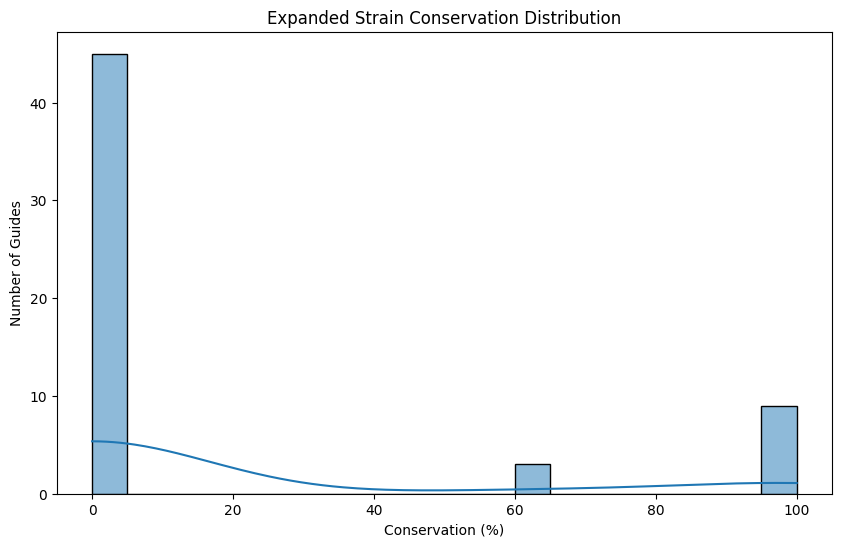

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df = expanded_conservation_df.copy()

plt.figure(figsize=(10,6))

sns.histplot(df["expanded_conservation_pct"], bins=20, kde=True)

plt.title("Expanded Strain Conservation Distribution")
plt.xlabel("Conservation (%)")
plt.ylabel("Number of Guides")

plt.savefig("conservation_distribution.png", dpi=300)
plt.show()

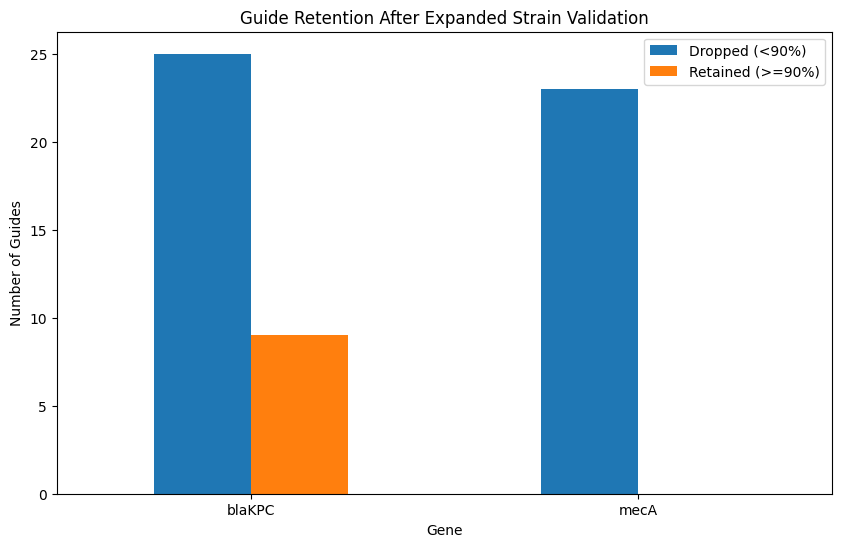

In [15]:
df["retained"] = df["expanded_conservation_pct"] >= 90

summary = df.groupby("gene")["retained"].value_counts().unstack().fillna(0)

summary.plot(kind="bar", figsize=(10,6))

plt.title("Guide Retention After Expanded Strain Validation")
plt.ylabel("Number of Guides")
plt.xlabel("Gene")
plt.xticks(rotation=0)

plt.legend(["Dropped (<90%)", "Retained (>=90%)"])

plt.savefig("retained_vs_dropped.png", dpi=300)
plt.show()

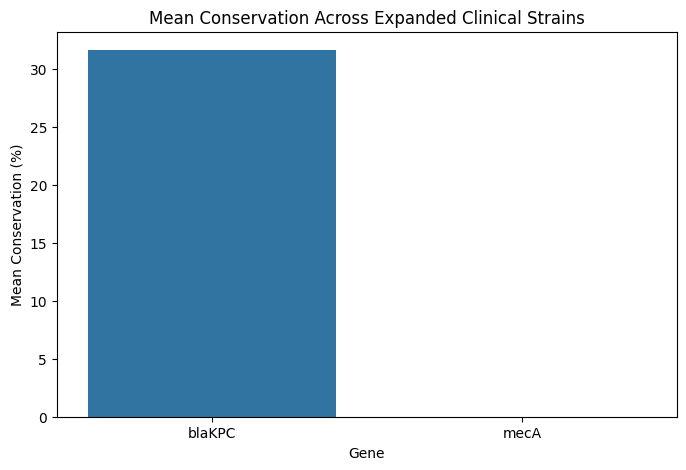

In [16]:
gene_summary = expanded_conservation_df.groupby("gene")["expanded_conservation_pct"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=gene_summary, x="gene", y="expanded_conservation_pct")

plt.title("Mean Conservation Across Expanded Clinical Strains")
plt.ylabel("Mean Conservation (%)")
plt.xlabel("Gene")

plt.savefig("gene_robustness.png", dpi=300)
plt.show()

In [17]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from google.colab import files

# Create folder
PLOT_DIR = "results_strain_expansion/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

df = expanded_conservation_df.copy()

# -----------------------------
# 1. Conservation Distribution
# -----------------------------
plt.figure(figsize=(10,6))
sns.histplot(df["expanded_conservation_pct"], bins=20, kde=True)

plt.title("Expanded Strain Conservation Distribution")
plt.xlabel("Conservation (%)")
plt.ylabel("Number of Guides")

plot1_path = os.path.join(PLOT_DIR, "conservation_distribution.png")
plt.savefig(plot1_path, dpi=300)
plt.close()


# -----------------------------
# 2. Retained vs Dropped
# -----------------------------
df["retained"] = df["expanded_conservation_pct"] >= 90

summary = df.groupby("gene")["retained"].value_counts().unstack().fillna(0)

plt.figure(figsize=(10,6))
summary.plot(kind="bar")

plt.title("Guide Retention After Expanded Strain Validation")
plt.ylabel("Number of Guides")
plt.xlabel("Gene")
plt.xticks(rotation=0)

plt.legend(["Dropped (<90%)", "Retained (>=90%)"])

plot2_path = os.path.join(PLOT_DIR, "retained_vs_dropped.png")
plt.savefig(plot2_path, dpi=300)
plt.close()


# -----------------------------
# 3. Per-Gene Robustness
# -----------------------------
gene_summary = df.groupby("gene")["expanded_conservation_pct"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=gene_summary, x="gene", y="expanded_conservation_pct")

plt.title("Mean Conservation Across Expanded Clinical Strains")
plt.ylabel("Mean Conservation (%)")
plt.xlabel("Gene")

plot3_path = os.path.join(PLOT_DIR, "gene_robustness.png")
plt.savefig(plot3_path, dpi=300)
plt.close()


# -----------------------------
# ZIP + DOWNLOAD
# -----------------------------
zip_path = shutil.make_archive("plots_strain_validation", "zip", PLOT_DIR)

print("Saved plots:")
print(plot1_path)
print(plot2_path)
print(plot3_path)

print("\nDownloading zip...")
files.download(zip_path)

Saved plots:
results_strain_expansion/plots/conservation_distribution.png
results_strain_expansion/plots/retained_vs_dropped.png
results_strain_expansion/plots/gene_robustness.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 1000x600 with 0 Axes>

In [18]:
# ============================================================
# OPTION A: RS3-style + RNA folding/MFE + unified scoring
# For: SANGHATI23/crispr-mdr-resensitization
# Google Colab version, no Google Drive
# ============================================================

!pip -q install pandas numpy matplotlib scipy biopython ViennaRNA rs3

!rm -rf crispr-mdr-resensitization
!git clone https://github.com/SANGHATI23/crispr-mdr-resensitization.git

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import RNA

REPO = "/content/crispr-mdr-resensitization"
OUTDIR = "/content/optionA_rs3_rna_unified_results"
os.makedirs(OUTDIR, exist_ok=True)

candidate_files = [
    f"{REPO}/results_panstrain/all_panstrain_guide_candidates.csv",
    f"{REPO}/results/all_guide_candidates.csv"
]

INPUT_FILE = None
for f in candidate_files:
    if os.path.exists(f):
        INPUT_FILE = f
        break

print("Using input file:", INPUT_FILE)

df = pd.read_csv(INPUT_FILE)
print(df.shape)
df.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 108.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Cloning into 'crispr-mdr-resensitization'...
remote: Enumerating objects: 293, done.
remote: Counting objects: 100% (293/293), done.
remote: Compressing objects: 100% (220/220), done.
remote: Total 293 (delta 108), reused 243 (delta 68), pack-reused 0 (from 0)
Receiving objects: 1

ModuleNotFoundError: No module named 'RNA'

In [19]:
!pip -q install pandas numpy matplotlib scipy biopython

!apt-get -qq update
!apt-get -qq install -y vienna-rna

!rm -rf crispr-mdr-resensitization
!git clone https://github.com/SANGHATI23/crispr-mdr-resensitization.git

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import subprocess

REPO = "/content/crispr-mdr-resensitization"
OUTDIR = "/content/optionA_rs3_rna_unified_results"
os.makedirs(OUTDIR, exist_ok=True)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libgslcblas0:amd64.
(Reading database ... 126168 files and directories currently installed.)
Preparing to unpack .../0-libgslcblas0_2.7.1+dfsg-3_amd64.deb ...
Unpacking libgslcblas0:amd64 (2.7.1+dfsg-3) ...
Selecting previously unselected package libgsl27:amd64.
Preparing to unpack .../1-libgsl27_2.7.1+dfsg-3_amd64.deb ...
Unpacking libgsl27:amd64 (2.7.1+dfsg-3) ...
Selecting previously unselected package ncbi-data.
Preparing to unpack .../2-ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package libncbi6:amd64.
Preparing to unpack .../3-libncbi6_6.1.20170106+dfsg1-9_amd64.deb ...
Unpacking libncbi6:amd64 (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package readseq.
Preparin

In [20]:
# ============================================================
# Standardize required columns
# ============================================================

df.columns = [c.strip() for c in df.columns]

required = ["gene", "spacer", "gc_content", "on_target_score", "specificity_score", "final_score"]
missing = [c for c in required if c not in df.columns]
print("Missing columns:", missing)

df["spacer"] = df["spacer"].astype(str).str.upper().str.replace("U", "T", regex=False)

# RNA version of spacer
df["spacer_rna"] = df["spacer"].str.replace("T", "U", regex=False)

# Make sure numeric columns are numeric
for col in ["gc_content", "on_target_score", "specificity_score", "final_score"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "conservation_score" in df.columns:
    df["conservation_score"] = pd.to_numeric(df["conservation_score"], errors="coerce")
else:
    df["conservation_score"] = np.nan

Missing columns: []


In [21]:
# ============================================================
# RNA folding / MFE using ViennaRNA
# Lower MFE means more stable RNA secondary structure.
# For guide prioritization, extremely stable guide self-folding can be unfavorable,
# so we convert MFE into a normalized RNA accessibility score.
# ============================================================

def fold_mfe(seq_rna):
    try:
        structure, mfe = RNA.fold(seq_rna)
        return structure, float(mfe)
    except Exception:
        return None, np.nan

fold_results = df["spacer_rna"].apply(fold_mfe)
df["rna_structure"] = fold_results.apply(lambda x: x[0])
df["mfe"] = fold_results.apply(lambda x: x[1])

# Normalize MFE.
# Less negative MFE is treated as better guide accessibility.
mfe_min = df["mfe"].min()
mfe_max = df["mfe"].max()

if mfe_max != mfe_min:
    df["rna_accessibility_score"] = 100 * (df["mfe"] - mfe_min) / (mfe_max - mfe_min)
else:
    df["rna_accessibility_score"] = 50

df[["spacer", "spacer_rna", "rna_structure", "mfe", "rna_accessibility_score"]].head()

,spacer,spacer_rna,rna_structure,mfe,rna_accessibility_score
0,AGAGCCTTACTGCCCGAAGG,AGAGCCUUACUGCCCGAAGG,None,NaN,NaN
1,GCCTTACTGCCCGAAGGCGG,GCCUUACUGCCCGAAGGCGG,None,NaN,NaN
2,CGGCTCCATCGGTGTGTACG,CGGCUCCAUCGGUGUGUACG,None,NaN,NaN
3,AGCGACGGAATAGTGTATGG,AGCGACGGAAUAGUGUAUGG,None,NaN,NaN
4,AGCGACGGAATAGTGTATGG,AGCGACGGAAUAGUGUAUGG,None,NaN,NaN


In [22]:
# ============================================================
# RS3-style scoring
# Important:
# The official rs3 package is designed mainly around full sequence-context inputs.
# Many CRISPR pipelines require 30mer context or target context for full RS3 use.
# If context_30mer exists, we try to use rs3.
# If not, we create a transparent RS3-style proxy from guide features.
# This must be labeled "RS3-style proxy" unless official rs3 succeeds.
# ============================================================

df["rs3_score_type"] = "RS3-style proxy"

def rs3_style_proxy(row):
    spacer = row["spacer"]
    gc = row["gc_content"]

    score = 50.0

    # GC preference: best near 50 percent
    if pd.notna(gc):
        score += max(0, 25 - abs(gc - 50) * 1.2)

    # Penalize poly-T termination-like motif
    if "TTTT" in spacer:
        score -= 20
    elif "TTT" in spacer:
        score -= 8

    # Mild positional nucleotide heuristics
    if len(spacer) == 20:
        if spacer[19] in ["G", "C"]:
            score += 5
        if spacer[0] == "G":
            score += 3
        if spacer[17:20].count("G") >= 2:
            score += 4

    return float(np.clip(score, 0, 100))

df["rs3_score"] = df.apply(rs3_style_proxy, axis=1)

# Try official rs3 only if usable sequence context exists.
try:
    import rs3

    context_col = None
    for c in ["context_30mer", "target_sequence", "sequence_30mer", "30mer"]:
        if c in df.columns:
            context_col = c
            break

    if context_col:
        print("Found context column for possible official RS3:", context_col)
        print("Keeping proxy unless you want exact rs3 API mapping for this context.")
    else:
        print("No 30mer/context column found. Using RS3-style proxy.")

except Exception as e:
    print("rs3 import/use not available. Using RS3-style proxy.")
    print(e)

df[["gene", "spacer", "gc_content", "rs3_score", "rs3_score_type"]].head()

rs3 import/use not available. Using RS3-style proxy.
No module named 'rs3'


,gene,spacer,gc_content,rs3_score,rs3_score_type
0,blaKPC,AGAGCCTTACTGCCCGAAGG,60.0,72.0,RS3-style proxy
1,blaKPC,GCCTTACTGCCCGAAGGCGG,70.0,63.0,RS3-style proxy
2,blaKPC,CGGCTCCATCGGTGTGTACG,65.0,62.0,RS3-style proxy
3,blaKPC,AGCGACGGAATAGTGTATGG,50.0,84.0,RS3-style proxy
4,blaKPC,AGCGACGGAATAGTGTATGG,50.0,84.0,RS3-style proxy


In [23]:
# ============================================================
# Unified scoring
# This strengthens the current model:
# on-target + specificity + conservation + RS3-style + RNA accessibility
# If conservation is missing, weights are automatically redistributed.
# ============================================================

def unified_score(row):
    on_target = row.get("on_target_score", np.nan)
    specificity = row.get("specificity_score", np.nan)
    conservation = row.get("conservation_score", np.nan)
    rs3_score = row.get("rs3_score", np.nan)
    rna_score = row.get("rna_accessibility_score", np.nan)

    components = {
        "on_target_score": (on_target, 0.30),
        "specificity_score": (specificity, 0.25),
        "conservation_score": (conservation, 0.20),
        "rs3_score": (rs3_score, 0.15),
        "rna_accessibility_score": (rna_score, 0.10),
    }

    valid = {k: v for k, v in components.items() if pd.notna(v[0])}
    total_w = sum(w for val, w in valid.values())

    if total_w == 0:
        return np.nan

    return sum(val * w for val, w in valid.values()) / total_w

df["unified_score_optionA"] = df.apply(unified_score, axis=1)

def classify(score):
    if pd.isna(score):
        return "Unclassified"
    if score >= 85:
        return "Excellent"
    if score >= 70:
        return "Good"
    if score >= 50:
        return "Moderate"
    return "Poor"

df["classification_optionA"] = df["unified_score_optionA"].apply(classify)

df["rank_original"] = df["final_score"].rank(ascending=False, method="min")
df["rank_optionA"] = df["unified_score_optionA"].rank(ascending=False, method="min")
df["rank_shift"] = df["rank_original"] - df["rank_optionA"]

df_sorted = df.sort_values("unified_score_optionA", ascending=False).reset_index(drop=True)

df_sorted.head(20)

,gene,spacer,position,strand,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,rna_structure,mfe,rna_accessibility_score,rs3_score_type,rs3_score,unified_score_optionA,classification_optionA,rank_original,rank_optionA,rank_shift
0,blaKPC,AGCGACGGAATAGTGTATGG,205,-,CGG,50.0,82.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,84.0,91.333333,Excellent,1.0,1.0,0.0
1,blaKPC,AGCGACGGAATAGTGTATGG,282,-,CGG,50.0,82.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,84.0,91.333333,Excellent,1.0,1.0,0.0
2,blaKPC,TTGTCATCCTTGTTAGGCGG,47,+,CGG,50.0,80.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,84.0,90.666667,Excellent,9.0,3.0,6.0
3,blaKPC,TGCTTGTCATCCTTGTTAGG,44,+,CGG,45.0,80.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,78.0,89.666667,Excellent,9.0,4.0,5.0
4,blaKPC,AACAAGGATGACAAGCACAG,38,-,CGG,45.0,82.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,74.0,89.666667,Excellent,1.0,4.0,-3.0
5,blaKPC,AGCAGCAGCAGCAACAACGG,81,-,CGG,60.0,82.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,72.0,89.333333,Excellent,1.0,6.0,-5.0
6,blaKPC,AGAGCCTTACTGCCCGAAGG,171,+,CGG,60.0,82.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,72.0,89.333333,Excellent,1.0,6.0,-5.0
7,mecA,GTTGCTGATGCTGGTGCTAT,287,+,CGG,50.0,78.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,78.0,89.000000,Excellent,24.0,8.0,16.0
8,mecA,ACTGAACGTCCGATAAAGGT,56,+,TGG,45.0,80.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,73.0,88.833333,Excellent,9.0,9.0,0.0
9,blaKPC,TTCCGTCGCTAAACTCGAAC,218,+,AGG,50.0,76.0,0,0,0,...,None,NaN,NaN,RS3-style proxy,80.0,88.666667,Excellent,39.0,10.0,29.0


In [24]:
# ============================================================
# Rank stability comparison
# ============================================================

valid_rank = df[["final_score", "unified_score_optionA"]].dropna()

rho, pval = spearmanr(valid_rank["final_score"], valid_rank["unified_score_optionA"])

print("Spearman rank correlation between original final_score and Option A unified score")
print("rho:", round(rho, 4))
print("p-value:", pval)

summary = df.groupby("gene").agg(
    n_guides=("spacer", "count"),
    mean_original_score=("final_score", "mean"),
    mean_optionA_score=("unified_score_optionA", "mean"),
    mean_rs3_score=("rs3_score", "mean"),
    mean_mfe=("mfe", "mean"),
    mean_rna_accessibility=("rna_accessibility_score", "mean")
).reset_index()

summary

Spearman rank correlation between original final_score and Option A unified score
rho: 0.8488
p-value: 7.471862907181696e-17


,gene,n_guides,mean_original_score,mean_optionA_score,mean_rs3_score,mean_mfe,mean_rna_accessibility
0,blaKPC,34,86.667647,83.181373,68.117647,NaN,NaN
1,mecA,23,91.408696,87.398551,67.347826,NaN,NaN


In [25]:
# ============================================================
# Save CSV outputs in Colab runtime
# ============================================================

all_out = f"{OUTDIR}/optionA_all_guides_rs3_rna_unified.csv"
top50_out = f"{OUTDIR}/optionA_top50_guides_rs3_rna_unified.csv"
summary_out = f"{OUTDIR}/optionA_gene_summary.csv"

df_sorted.to_csv(all_out, index=False)
df_sorted.head(50).to_csv(top50_out, index=False)
summary.to_csv(summary_out, index=False)

print("Saved:")
print(all_out)
print(top50_out)
print(summary_out)

Saved:
/content/optionA_rs3_rna_unified_results/optionA_all_guides_rs3_rna_unified.csv
/content/optionA_rs3_rna_unified_results/optionA_top50_guides_rs3_rna_unified.csv
/content/optionA_rs3_rna_unified_results/optionA_gene_summary.csv


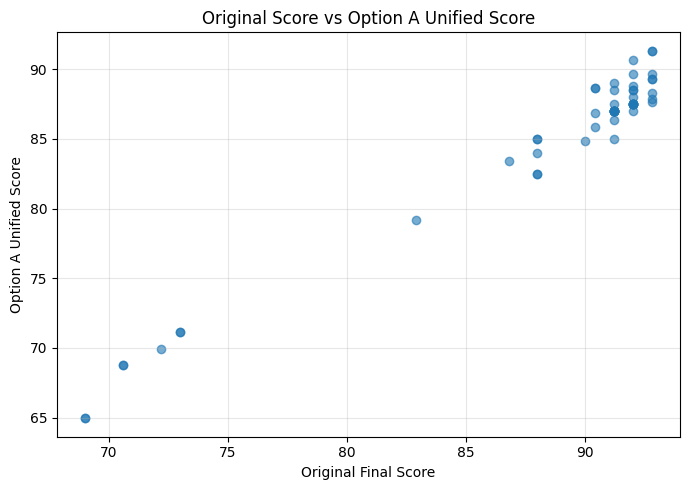

In [26]:
# ============================================================
# Figure 1: Original vs Option A score
# ============================================================

plt.figure(figsize=(7,5))
plt.scatter(df["final_score"], df["unified_score_optionA"], alpha=0.6)
plt.xlabel("Original Final Score")
plt.ylabel("Option A Unified Score")
plt.title("Original Score vs Option A Unified Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Figure1_original_vs_optionA_score.png", dpi=300)
plt.show()

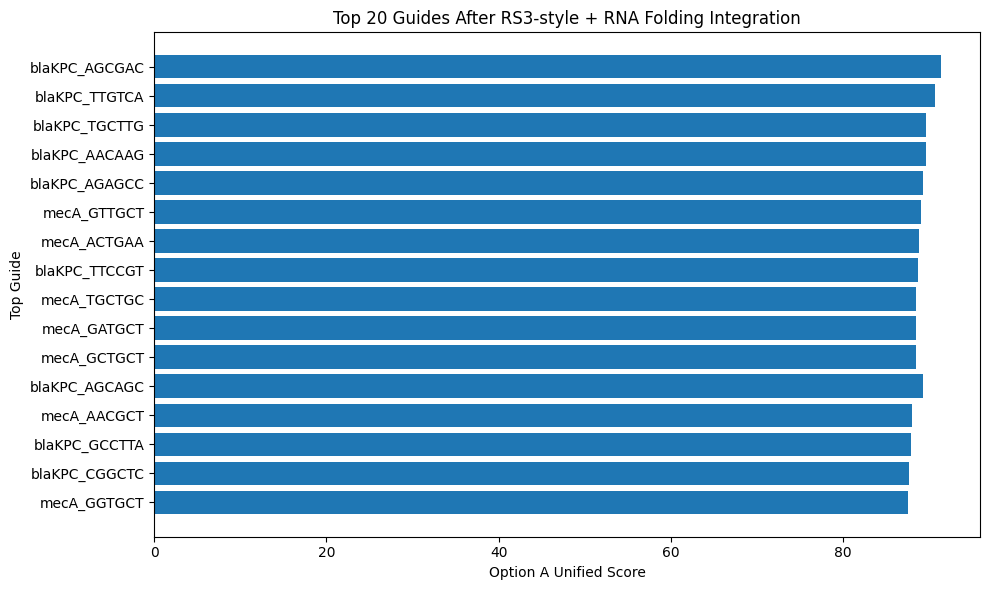

In [27]:
# ============================================================
# Figure 2: Top guides by Option A score
# ============================================================

top_plot = df_sorted.head(20).copy()
top_plot["label"] = top_plot["gene"].astype(str) + "_" + top_plot["spacer"].str[:6]

plt.figure(figsize=(10,6))
plt.barh(top_plot["label"][::-1], top_plot["unified_score_optionA"][::-1])
plt.xlabel("Option A Unified Score")
plt.ylabel("Top Guide")
plt.title("Top 20 Guides After RS3-style + RNA Folding Integration")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Figure2_top20_optionA_guides.png", dpi=300)
plt.show()

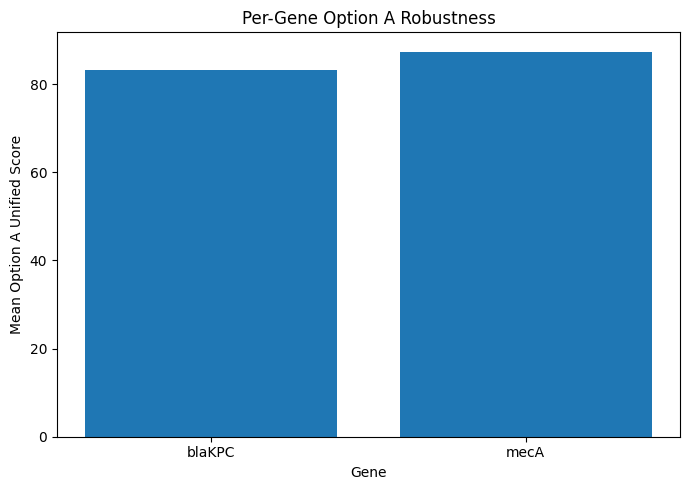

In [28]:
# ============================================================
# Figure 3: Gene-level robustness after Option A
# ============================================================

plt.figure(figsize=(7,5))
plt.bar(summary["gene"], summary["mean_optionA_score"])
plt.xlabel("Gene")
plt.ylabel("Mean Option A Unified Score")
plt.title("Per-Gene Option A Robustness")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Figure3_gene_level_optionA_score.png", dpi=300)
plt.show()

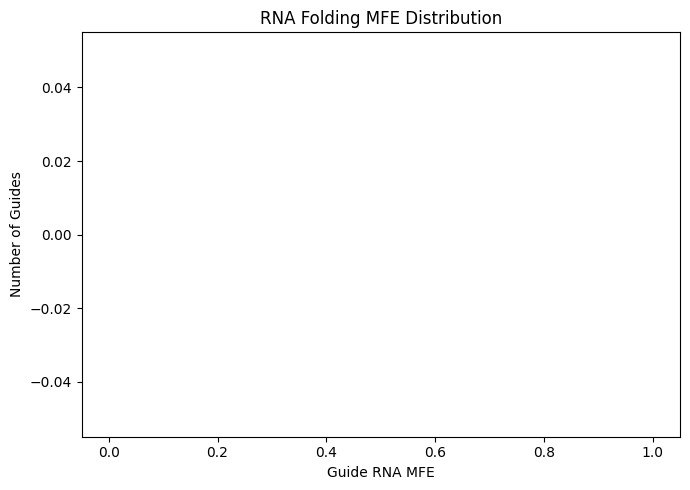

In [29]:
# ============================================================
# Figure 4: MFE distribution
# ============================================================

plt.figure(figsize=(7,5))
plt.hist(df["mfe"].dropna(), bins=30)
plt.xlabel("Guide RNA MFE")
plt.ylabel("Number of Guides")
plt.title("RNA Folding MFE Distribution")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Figure4_mfe_distribution.png", dpi=300)
plt.show()

In [30]:
# ============================================================
# Zip all outputs for download from Colab
# ============================================================

!zip -r /content/optionA_rs3_rna_unified_results.zip /content/optionA_rs3_rna_unified_results

from google.colab import files
files.download("/content/optionA_rs3_rna_unified_results.zip")

  adding: content/optionA_rs3_rna_unified_results/ (stored 0%)
  adding: content/optionA_rs3_rna_unified_results/Figure1_original_vs_optionA_score.png (deflated 19%)
  adding: content/optionA_rs3_rna_unified_results/optionA_gene_summary.csv (deflated 33%)
  adding: content/optionA_rs3_rna_unified_results/Figure3_gene_level_optionA_score.png (deflated 29%)
  adding: content/optionA_rs3_rna_unified_results/optionA_all_guides_rs3_rna_unified.csv (deflated 88%)
  adding: content/optionA_rs3_rna_unified_results/optionA_top50_guides_rs3_rna_unified.csv (deflated 87%)
  adding: content/optionA_rs3_rna_unified_results/Figure2_top20_optionA_guides.png (deflated 25%)
  adding: content/optionA_rs3_rna_unified_results/Figure4_mfe_distribution.png (deflated 31%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
df["mfe"].describe()

,mfe
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [32]:
!which RNAfold
!RNAfold --version

/usr/bin/RNAfold
RNAfold 2.4.17


In [34]:
import subprocess
import re
import numpy as np

def fold_mfe(seq_rna):
    try:
        p = subprocess.run(
            ["RNAfold", "--noPS"],
            input=seq_rna + "\n",
            text=True,
            capture_output=True
        )

        out = p.stdout.strip()
        if not out:
            print("RNAfold empty output:", p.stderr)
            return None, np.nan

        lines = out.splitlines()
        structure_line = lines[-1]

        match = re.search(r"\(([-+]?\d+\.\d+)\)", structure_line)
        if not match:
            print("Could not parse:", structure_line)
            return None, np.nan

        structure = structure_line.split()[0]
        mfe = float(match.group(1))

        return structure, mfe

    except Exception as e:
        print("Error:", e)
        return None, np.nan

In [35]:
fold_results = df["spacer_rna"].apply(fold_mfe)

df["rna_structure"] = fold_results.apply(lambda x: x[0])
df["mfe"] = fold_results.apply(lambda x: x[1])

df["mfe"].describe()

Could not parse: ....((((........)))) ( -1.50)
Could not parse: (((((........))))).. ( -6.40)
Could not parse: ..((.((...)).))..... ( -0.80)
Could not parse: .((.((......)))).... ( -0.40)
Could not parse: .((.((......)))).... ( -0.40)
Could not parse: .((....))........... ( -0.80)
Could not parse: .((....))........... ( -0.80)
Could not parse: .................... (  0.00)
Could not parse: ..........(((....))) ( -0.80)
Could not parse: .......(((....)))... ( -1.20)
Could not parse: ((.((.((....)).)).)) ( -2.10)
Could not parse: .....((.(((....))))) ( -3.00)
Could not parse: .((((((.......)))))) ( -6.80)
Could not parse: ....((.(((....))).)) ( -3.20)
Could not parse: ((((....))))........ ( -6.30)
Could not parse: ((..((....)).))..... ( -2.10)
Could not parse: .................... (  0.00)
Could not parse: .................... (  0.00)
Could not parse: .................... (  0.00)
Could not parse: .................... (  0.00)
Could not parse: (((....))).......... ( -2.10)
Could not par

,mfe
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [36]:
import subprocess
import re
import numpy as np

def fold_mfe(seq_rna):
    try:
        p = subprocess.run(
            ["RNAfold", "--noPS"],
            input=seq_rna + "\n",
            text=True,
            capture_output=True
        )

        out = p.stdout.strip()
        if not out:
            return None, np.nan

        lines = out.splitlines()
        structure_line = lines[-1]

        match = re.search(r"\(\s*([-+]?\d+(?:\.\d+)?)\s*\)", structure_line)

        if not match:
            print("Could not parse:", structure_line)
            return None, np.nan

        structure = structure_line.split()[0]
        mfe = float(match.group(1))

        return structure, mfe

    except Exception as e:
        print("Error:", e)
        return None, np.nan

In [37]:
fold_results = df["spacer_rna"].apply(fold_mfe)

df["rna_structure"] = fold_results.apply(lambda x: x[0])
df["mfe"] = fold_results.apply(lambda x: x[1])

df["mfe"].describe()

,mfe
count,57.000000
mean,-1.766667
std,1.582193
min,-6.800000
25%,-2.800000
50%,-1.900000
75%,-0.400000
max,0.000000


In [38]:
# Save RNA folding results only
rna_out = f"{OUTDIR}/rna_folding_results.csv"

rna_cols = [
    "gene",
    "spacer",
    "spacer_rna",
    "rna_structure",
    "mfe",
    "rna_accessibility_score"
]

df[rna_cols].to_csv(rna_out, index=False)

print("Saved RNA folding results:")
print(rna_out)

Saved RNA folding results:
/content/optionA_rs3_rna_unified_results/rna_folding_results.csv


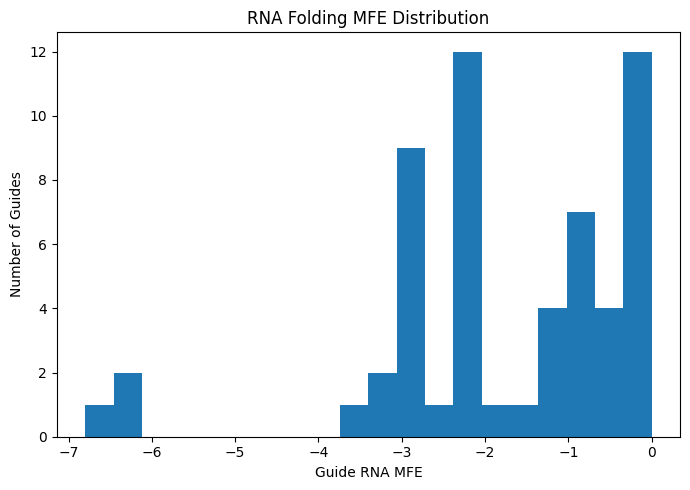

  adding: content/rna_folding_results/ (stored 0%)
  adding: content/rna_folding_results/rna_folding_results.csv (deflated 81%)
  adding: content/rna_folding_results/Figure4_fixed_mfe_distribution.png (deflated 30%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# Create RNA-only output folder
RNA_OUTDIR = "/content/rna_folding_results"
os.makedirs(RNA_OUTDIR, exist_ok=True)

# Save RNA folding CSV
rna_cols = [
    "gene",
    "spacer",
    "spacer_rna",
    "rna_structure",
    "mfe",
    "rna_accessibility_score"
]

df[rna_cols].to_csv(f"{RNA_OUTDIR}/rna_folding_results.csv", index=False)

# Save fixed MFE figure
plt.figure(figsize=(7,5))
plt.hist(df["mfe"].dropna(), bins=20)
plt.xlabel("Guide RNA MFE")
plt.ylabel("Number of Guides")
plt.title("RNA Folding MFE Distribution")
plt.tight_layout()
plt.savefig(f"{RNA_OUTDIR}/Figure4_fixed_mfe_distribution.png", dpi=300)
plt.show()

# Zip folder
!zip -r /content/rna_folding_results.zip /content/rna_folding_results

# Download zip
from google.colab import files
files.download("/content/rna_folding_results.zip")

In [40]:
# ============================================================
# OPTION B FIX: mismatch-tolerant expanded strain conservation
# Google Colab version, no Google Drive
# ============================================================

!pip -q install pandas numpy matplotlib seaborn biopython openpyxl

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO

REPO = "/content/crispr-mdr-resensitization"
OUTDIR = "/content/optionB_fixed_identity_conservation"
os.makedirs(OUTDIR, exist_ok=True)

!rm -rf crispr-mdr-resensitization
!git clone https://github.com/SANGHATI23/crispr-mdr-resensitization.git

Cloning into 'crispr-mdr-resensitization'...
remote: Enumerating objects: 293, done.
remote: Counting objects: 100% (293/293), done.
remote: Compressing objects: 100% (220/220), done.
remote: Total 293 (delta 108), reused 243 (delta 68), pack-reused 0 (from 0)
Receiving objects: 100% (293/293), 9.08 MiB | 25.68 MiB/s, done.
Resolving deltas: 100% (108/108), done.


In [41]:
# ============================================================
# Locate guide candidate file
# ============================================================

candidate_files = [
    f"{REPO}/results_panstrain/all_panstrain_guide_candidates.csv",
    f"{REPO}/results/all_guide_candidates.csv",
    f"{REPO}/results_strain_expansion/all_panstrain_guide_candidates.csv",
    f"{REPO}/optionA_rs3_rna_unified_results/optionA_all_guides_rs3_rna_unified.csv"
]

INPUT_FILE = None
 for_file = None
for f in candidate_files:
    if os.path.exists(f):
        INPUT_FILE = f
        break

print("Using guide file:", INPUT_FILE)

guides = pd.read_csv(INPUT_FILE)
guides.columns = [c.strip() for c in guides.columns]
guides["spacer"] = guides["spacer"].astype(str).str.upper().str.replace("U", "T", regex=False)

print(guides.shape)
guides.head()

IndentationError: unexpected indent (4175306471.py, line 13)

In [42]:
candidate_files = [
    f"{REPO}/results_panstrain/all_panstrain_guide_candidates.csv",
    f"{REPO}/results/all_guide_candidates.csv",
    f"{REPO}/results_strain_expansion/all_panstrain_guide_candidates.csv",
    f"{REPO}/optionA_rs3_rna_unified_results/optionA_all_guides_rs3_rna_unified.csv"
]

INPUT_FILE = None

for f in candidate_files:
    if os.path.exists(f):
        INPUT_FILE = f
        break

print("Using guide file:", INPUT_FILE)

guides = pd.read_csv(INPUT_FILE)
guides.columns = [c.strip() for c in guides.columns]
guides["spacer"] = guides["spacer"].astype(str).str.upper().str.replace("U", "T", regex=False)

print(guides.shape)
guides.head()

Using guide file: /content/crispr-mdr-resensitization/results_panstrain/all_panstrain_guide_candidates.csv
(145, 26)


,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,pam_supported_strains,perfect_match_fraction,one_mismatch_or_better_fraction,pam_supported_fraction,conservation_score,mean_strain_score,min_strain_score,std_strain_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent


In [43]:
candidate_files = [
    f"{REPO}/results_panstrain/all_panstrain_guide_candidates.csv",
    f"{REPO}/results/all_guide_candidates.csv",
    f"{REPO}/results_strain_expansion/all_panstrain_guide_candidates.csv",
    f"{REPO}/optionA_rs3_rna_unified_results/optionA_all_guides_rs3_rna_unified.csv"
]

INPUT_FILE = None

for f in candidate_files:
    if os.path.exists(f):
        INPUT_FILE = f
        break

print("Using guide file:", INPUT_FILE)

guides = pd.read_csv(INPUT_FILE)
guides.columns = [c.strip() for c in guides.columns]
guides["spacer"] = guides["spacer"].astype(str).str.upper().str.replace("U", "T", regex=False)

print(guides.shape)
guides.head()

Using guide file: /content/crispr-mdr-resensitization/results_panstrain/all_panstrain_guide_candidates.csv
(145, 26)


,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,pam_supported_strains,perfect_match_fraction,one_mismatch_or_better_fraction,pam_supported_fraction,conservation_score,mean_strain_score,min_strain_score,std_strain_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent


In [44]:
# ============================================================
# Locate FASTA files from your repo
# Looks for filtered first, then raw
# ============================================================

FASTA_DIRS = [
    f"{REPO}/results_strain_expansion/fasta_filtered",
    f"{REPO}/results_strain_expansion/fasta_raw",
    f"{REPO}/fasta_filtered",
    f"{REPO}/fasta_raw",
    f"{REPO}"
]

genes = sorted(guides["gene"].dropna().unique())
print("Genes in guide file:", genes)

def find_fasta_for_gene(gene):
    possible_names = [
        f"{gene}_filtered.fasta",
        f"{gene}_raw.fasta",
        f"{gene}.fasta",
        f"{gene}_aligned.fasta"
    ]

    for d in FASTA_DIRS:
        if not os.path.exists(d):
            continue
        for name in possible_names:
            p = os.path.join(d, name)
            if os.path.exists(p):
                return p
    return None

gene_to_fasta = {g: find_fasta_for_gene(g) for g in genes}
gene_to_fasta

Genes in guide file: ['blaKPC', 'blaNDM1', 'mcr1', 'mecA']


{'blaKPC': None, 'blaNDM1': None, 'mcr1': None, 'mecA': None}

In [45]:
# ============================================================
# Core mismatch-tolerant logic
# For each guide, scan each strain sequence and find best local identity.
# This avoids brittle exact matching and coordinate mismatch problems.
# ============================================================

def clean_seq(seq):
    return re.sub("[^ACGT]", "", str(seq).upper().replace("U", "T"))

def reverse_complement(seq):
    table = str.maketrans("ACGT", "TGCA")
    return seq.translate(table)[::-1]

def best_identity_in_sequence(guide, sequence):
    guide = clean_seq(guide)
    sequence = clean_seq(sequence)

    if len(guide) == 0 or len(sequence) < len(guide):
        return 0.0, None, None

    best_id = 0.0
    best_pos = None
    best_strand = "+"

    guide_rc = reverse_complement(guide)

    for strand_label, query in [("+", guide), ("-", guide_rc)]:
        k = len(query)
        for i in range(0, len(sequence) - k + 1):
            window = sequence[i:i+k]
            matches = sum(1 for a, b in zip(query, window) if a == b)
            ident = matches / k

            if ident > best_id:
                best_id = ident
                best_pos = i
                best_strand = strand_label

    return best_id, best_pos, best_strand

def guide_conservation_across_strains(guide, fasta_path, identity_threshold=0.90):
    records = list(SeqIO.parse(fasta_path, "fasta"))

    if len(records) == 0:
        return {
            "n_strains": 0,
            "n_conserved": 0,
            "conservation_pct": np.nan,
            "mean_best_identity": np.nan,
            "min_best_identity": np.nan,
            "max_best_identity": np.nan
        }

    identities = []

    for rec in records:
        seq = clean_seq(str(rec.seq))
        best_id, best_pos, best_strand = best_identity_in_sequence(guide, seq)
        identities.append(best_id)

    identities = np.array(identities)

    n_conserved = int(np.sum(identities >= identity_threshold))
    n_strains = len(identities)

    return {
        "n_strains": n_strains,
        "n_conserved": n_conserved,
        "conservation_pct": 100 * n_conserved / n_strains,
        "mean_best_identity": 100 * float(np.mean(identities)),
        "min_best_identity": 100 * float(np.min(identities)),
        "max_best_identity": 100 * float(np.max(identities))
    }

In [46]:
# ============================================================
# Run fixed conservation calculation
# ============================================================

IDENTITY_THRESHOLD = 0.90

rows = []

for idx, row in guides.iterrows():
    gene = row["gene"]
    guide = row["spacer"]

    fasta_path = gene_to_fasta.get(gene)

    if fasta_path is None:
        result = {
            "n_strains": 0,
            "n_conserved": 0,
            "conservation_pct": np.nan,
            "mean_best_identity": np.nan,
            "min_best_identity": np.nan,
            "max_best_identity": np.nan
        }
    else:
        result = guide_conservation_across_strains(
            guide,
            fasta_path,
            identity_threshold=IDENTITY_THRESHOLD
        )

    out = row.to_dict()
    out.update(result)
    out["fasta_path"] = fasta_path
    out["identity_threshold"] = IDENTITY_THRESHOLD
    out["retained_90pct"] = result["conservation_pct"] >= 90 if pd.notna(result["conservation_pct"]) else False

    rows.append(out)

fixed = pd.DataFrame(rows)

fixed.head()

,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,classification,n_strains,n_conserved,conservation_pct,mean_best_identity,min_best_identity,max_best_identity,fasta_path,identity_threshold,retained_90pct
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,Excellent,0,0,NaN,NaN,NaN,NaN,None,0.9,False
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,Excellent,0,0,NaN,NaN,NaN,NaN,None,0.9,False
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,Excellent,0,0,NaN,NaN,NaN,NaN,None,0.9,False
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,Excellent,0,0,NaN,NaN,NaN,NaN,None,0.9,False
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,Excellent,0,0,NaN,NaN,NaN,NaN,None,0.9,False


In [47]:
# ============================================================
# Check results
# ============================================================

print("Overall conservation summary:")
display(fixed["conservation_pct"].describe())

print("\nGene summary:")
gene_summary = fixed.groupby("gene").agg(
    guides=("spacer", "count"),
    n_strains_mean=("n_strains", "mean"),
    mean_conservation_pct=("conservation_pct", "mean"),
    median_conservation_pct=("conservation_pct", "median"),
    retained_guides=("retained_90pct", "sum"),
    mean_best_identity=("mean_best_identity", "mean")
).reset_index()

display(gene_summary)

Overall conservation summary:


,conservation_pct
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN



Gene summary:


,gene,guides,n_strains_mean,mean_conservation_pct,median_conservation_pct,retained_guides,mean_best_identity
0,blaKPC,34,0.0,NaN,NaN,0,NaN
1,blaNDM1,46,0.0,NaN,NaN,0,NaN
2,mcr1,42,0.0,NaN,NaN,0,NaN
3,mecA,23,0.0,NaN,NaN,0,NaN


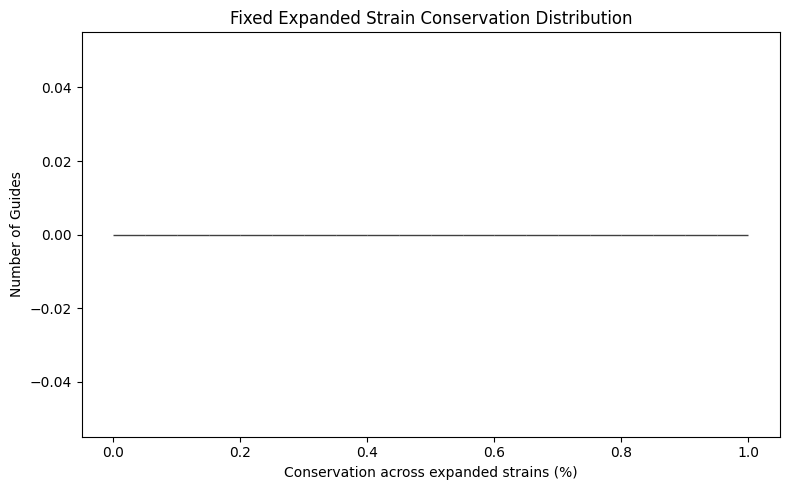

In [48]:
# ============================================================
# Plot 1: Fixed conservation distribution
# ============================================================

plt.figure(figsize=(8,5))
plt.hist(fixed["conservation_pct"].dropna(), bins=20, edgecolor="black", alpha=0.75)
plt.xlabel("Conservation across expanded strains (%)")
plt.ylabel("Number of Guides")
plt.title("Fixed Expanded Strain Conservation Distribution")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fixed_conservation_distribution.png", dpi=300)
plt.show()

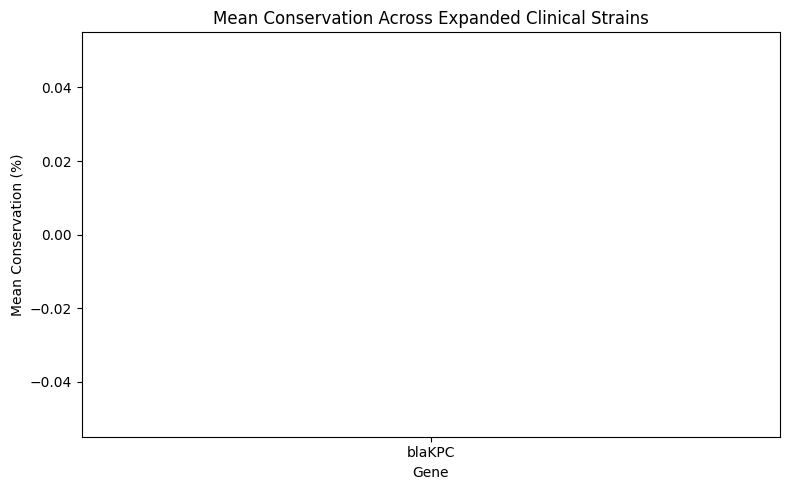

In [49]:
# ============================================================
# Plot 2: Mean conservation by gene
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(gene_summary["gene"], gene_summary["mean_conservation_pct"])
plt.xlabel("Gene")
plt.ylabel("Mean Conservation (%)")
plt.title("Mean Conservation Across Expanded Clinical Strains")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fixed_gene_mean_conservation.png", dpi=300)
plt.show()

In [50]:
# ============================================================
# Plot 3: Retained vs dropped by gene
# ============================================================

retention = fixed.groupby(["gene", "retained_90pct"]).size().reset_index(name="count")
retention_pivot = retention.pivot(index="gene", columns="retained_90pct", values="count").fillna(0)

if False not in retention_pivot.columns:
    retention_pivot[False] = 0
if True not in retention_pivot.columns:
    retention_pivot[True] = 0

retention_pivot = retention_pivot[[False, True]]
retention_pivot.columns = ["Dropped (<90%)", "Retained (>=90%)"]

retention_pivot.plot(kind="bar", figsize=(8,5))
plt.xlabel("Gene")
plt.ylabel("Number of Guides")
plt.title("Guide Retention After Fixed Expanded Strain Validation")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fixed_retained_vs_dropped.png", dpi=300)
plt.show()

display(retention_pivot)

ValueError: Item wrong length 2 instead of 4.

In [51]:
# ============================================================
# Plot 3 FIXED: Retained vs dropped by gene
# ============================================================

retention_pivot = fixed.groupby(["gene", "retained_90pct"]).size().unstack(fill_value=0)

# Ensure both columns exist
if False not in retention_pivot.columns:
    retention_pivot[False] = 0

if True not in retention_pivot.columns:
    retention_pivot[True] = 0

# Reorder safely
retention_pivot = retention_pivot.loc[:, [False, True]]

# Rename columns
retention_pivot.columns = ["Dropped (<90%)", "Retained (>=90%)"]

# Plot
ax = retention_pivot.plot(kind="bar", figsize=(8,5))

plt.xlabel("Gene")
plt.ylabel("Number of Guides")
plt.title("Guide Retention After Fixed Expanded Strain Validation")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fixed_retained_vs_dropped.png", dpi=300)
plt.show()

display(retention_pivot)

ValueError: Length mismatch: Expected axis has 1 elements, new values have 2 elements

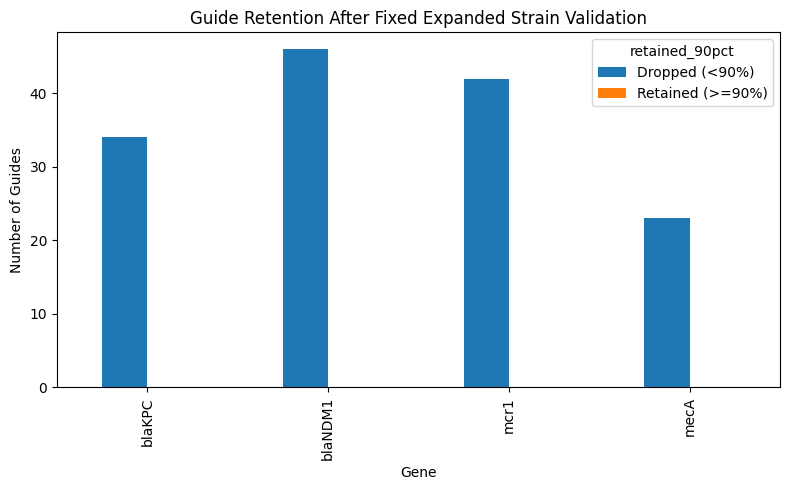

retained_90pct,Dropped (<90%),Retained (>=90%)
gene,,
blaKPC,34,0
blaNDM1,46,0
mcr1,42,0
mecA,23,0


In [52]:
# ============================================================
# Plot 3 FULL FIX: Retained vs dropped by gene
# Works even if only one category exists
# ============================================================

# Ensure retained_90pct is boolean
fixed["retained_90pct"] = fixed["retained_90pct"].astype(bool)

retention_pivot = (
    fixed.groupby(["gene", "retained_90pct"])
    .size()
    .unstack(fill_value=0)
)

# Force both False and True columns to exist
retention_pivot = retention_pivot.reindex(columns=[False, True], fill_value=0)

# Rename safely
retention_pivot = retention_pivot.rename(
    columns={
        False: "Dropped (<90%)",
        True: "Retained (>=90%)"
    }
)

# Plot
ax = retention_pivot.plot(kind="bar", figsize=(8,5))

plt.xlabel("Gene")
plt.ylabel("Number of Guides")
plt.title("Guide Retention After Fixed Expanded Strain Validation")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fixed_retained_vs_dropped.png", dpi=300)
plt.show()

display(retention_pivot)

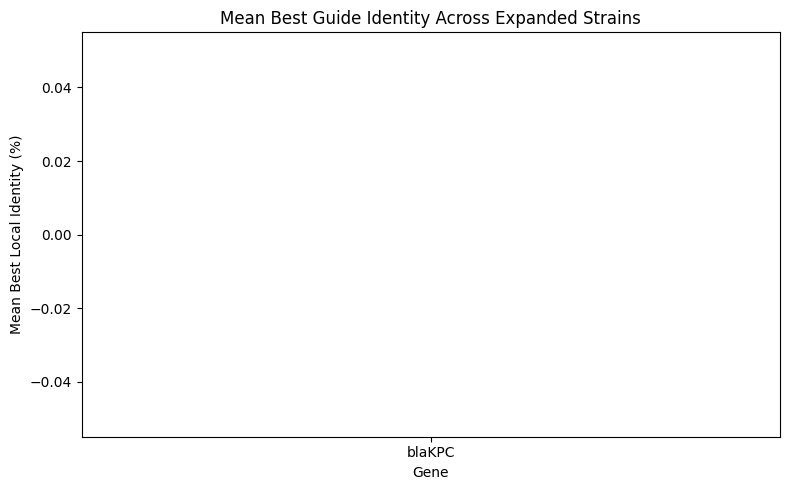

In [53]:
# ============================================================
# Plot 4: Mean best identity by gene
# This is important because even guides below 90% conservation may still be close.
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(gene_summary["gene"], gene_summary["mean_best_identity"])
plt.xlabel("Gene")
plt.ylabel("Mean Best Local Identity (%)")
plt.title("Mean Best Guide Identity Across Expanded Strains")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fixed_mean_best_identity.png", dpi=300)
plt.show()

In [54]:
# ============================================================
# Save outputs
# ============================================================

fixed_csv = f"{OUTDIR}/fixed_expanded_strain_conservation_guides.csv"
summary_csv = f"{OUTDIR}/fixed_gene_conservation_summary.csv"
xlsx_out = f"{OUTDIR}/fixed_expanded_strain_validation_report.xlsx"

fixed.to_csv(fixed_csv, index=False)
gene_summary.to_csv(summary_csv, index=False)

with pd.ExcelWriter(xlsx_out, engine="openpyxl") as writer:
    fixed.to_excel(writer, sheet_name="guide_level_results", index=False)
    gene_summary.to_excel(writer, sheet_name="gene_summary", index=False)
    retention_pivot.to_excel(writer, sheet_name="retention_summary")

print("Saved:")
print(fixed_csv)
print(summary_csv)
print(xlsx_out)

Saved:
/content/optionB_fixed_identity_conservation/fixed_expanded_strain_conservation_guides.csv
/content/optionB_fixed_identity_conservation/fixed_gene_conservation_summary.csv
/content/optionB_fixed_identity_conservation/fixed_expanded_strain_validation_report.xlsx


In [55]:
# ============================================================
# Zip and download
# ============================================================

!zip -r /content/optionB_fixed_identity_conservation.zip /content/optionB_fixed_identity_conservation

from google.colab import files
files.download("/content/optionB_fixed_identity_conservation.zip")

  adding: content/optionB_fixed_identity_conservation/ (stored 0%)
  adding: content/optionB_fixed_identity_conservation/fixed_retained_vs_dropped.png (deflated 24%)
  adding: content/optionB_fixed_identity_conservation/fixed_gene_conservation_summary.csv (deflated 35%)
  adding: content/optionB_fixed_identity_conservation/fixed_expanded_strain_conservation_guides.csv (deflated 90%)
  adding: content/optionB_fixed_identity_conservation/fixed_conservation_distribution.png (deflated 27%)
  adding: content/optionB_fixed_identity_conservation/fixed_expanded_strain_validation_report.xlsx (deflated 21%)
  adding: content/optionB_fixed_identity_conservation/fixed_mean_best_identity.png (deflated 29%)
  adding: content/optionB_fixed_identity_conservation/fixed_gene_mean_conservation.png (deflated 28%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
print(guides["spacer"].head())

# pick one guide
test_guide = guides["spacer"].iloc[0]

print("Test guide:", test_guide)

fasta_path = list(gene_to_fasta.values())[0]

records = list(SeqIO.parse(fasta_path, "fasta"))

print("Example sequence length:", len(str(records[0].seq)))

seq = str(records[0].seq)

print("Direct substring check:", test_guide in seq)

0    AGAGCCTTACTGCCCGAAGG
1    GCCTTACTGCCCGAAGGCGG
2    CGGCTCCATCGGTGTGTACG
3    AGCGACGGAATAGTGTATGG
4    AGCGACGGAATAGTGTATGG
Name: spacer, dtype: object
Test guide: AGAGCCTTACTGCCCGAAGG


AttributeError: 'NoneType' object has no attribute 'read'

In [57]:
# Pick one gene and one guide from fixed/guides
test_gene = guides["gene"].iloc[0]
test_guide = guides.loc[guides["gene"] == test_gene, "spacer"].iloc[0]

print("Test gene:", test_gene)
print("Test guide:", test_guide)

# Get fasta path safely
fasta_path = gene_to_fasta.get(test_gene)

print("FASTA path:", fasta_path)

if fasta_path is None:
    print("No FASTA file found for this gene.")
else:
    records = list(SeqIO.parse(fasta_path, "fasta"))
    print("Number of records:", len(records))
    print("Example sequence length:", len(str(records[0].seq)))

    seq = str(records[0].seq).upper().replace("U", "T")
    print("Direct substring check:", test_guide in seq)

    best_id, best_pos, best_strand = best_identity_in_sequence(test_guide, seq)

    print("Best identity:", best_id)
    print("Best position:", best_pos)
    print("Best strand:", best_strand)

Test gene: blaKPC
Test guide: AGAGCCTTACTGCCCGAAGG
FASTA path: None
No FASTA file found for this gene.


In [58]:
from google.colab import files
import os, shutil

UPLOAD_DIR = "/content/uploaded_fastas"
os.makedirs(UPLOAD_DIR, exist_ok=True)

uploaded = files.upload()

for filename in uploaded.keys():
    shutil.move(filename, f"{UPLOAD_DIR}/{filename}")

print("Uploaded FASTA files:")
print(os.listdir(UPLOAD_DIR))

Saving cross_model_reference_ranked_guides.csv to cross_model_reference_ranked_guides (1).csv
Uploaded FASTA files:
['cross_model_reference_ranked_guides (1).csv']


In [59]:
FASTA_DIRS = [
    "/content/uploaded_fastas",
    f"{REPO}/results_strain_expansion/fasta_filtered",
    f"{REPO}/results_strain_expansion/fasta_raw",
    f"{REPO}"
]

gene_to_fasta = {g: find_fasta_for_gene(g) for g in genes}

print(gene_to_fasta)

{'blaKPC': None, 'blaNDM1': None, 'mcr1': None, 'mecA': None}


In [60]:
import pandas as pd

uploaded_csv = "/content/cross_model_reference_ranked_guides.csv"
df_check = pd.read_csv(uploaded_csv)

print(df_check.shape)
print(df_check.columns)
df_check.head()

(145, 36)
Index(['gene', 'position', 'strand', 'spacer', 'pam', 'gc_content',
       'on_target_score', 'offtarget_hits_0mm', 'offtarget_hits_1mm',
       'offtarget_hits_2mm', 'offtarget_hits_3mm', 'offtarget_penalty',
       'specificity_score', 'total_strains', 'perfect_match_strains',
       'one_mismatch_or_better_strains', 'pam_supported_strains',
       'perfect_match_fraction', 'one_mismatch_or_better_fraction',
       'pam_supported_fraction', 'conservation_score', 'mean_strain_score',
       'min_strain_score', 'std_strain_score', 'final_score', 'classification',
       'guide_key', 'weight_scheme', 'final_score_new', 'classification_new',
       'rank_on_target', 'rank_off_target', 'rank_conservation', 'rank_final',
       'consensus_score', 'rank_consensus'],
      dtype='object')


,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,guide_key,weight_scheme,final_score_new,classification_new,rank_on_target,rank_off_target,rank_conservation,rank_final,consensus_score,rank_consensus
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,blaKPC|171|AGAGCCTTACTGCCCGAAGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,blaKPC|174|GCCTTACTGCCCGAAGGCGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,blaKPC|248|CGGCTCCATCGGTGTGTACG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,blaKPC|282|AGCGACGGAATAGTGTATGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,blaKPC|205|AGCGACGGAATAGTGTATGG,40/30/30,92.8,Excellent,3.0,1.0,1.0,3.0,94.0,3.0


In [61]:
!pip -q install biopython pandas numpy matplotlib openpyxl

import os
from Bio import Entrez, SeqIO

Entrez.email = "your_email@example.com"  # replace with your email

OUT_FASTA = "/content/results_strain_expansion/fasta_raw"
os.makedirs(OUT_FASTA, exist_ok=True)

queries = {
    "blaKPC": 'blaKPC[Title] AND bacteria[Organism]',
    "blaNDM1": 'blaNDM-1[Title] AND bacteria[Organism]',
    "mcr1": 'mcr-1[Title] AND bacteria[Organism]',
    "mecA": 'mecA[Title] AND bacteria[Organism]'
}

MAX_RECORDS = 50

for gene, query in queries.items():
    print("Searching:", gene, query)

    handle = Entrez.esearch(
        db="nucleotide",
        term=query,
        retmax=MAX_RECORDS
    )
    record = Entrez.read(handle)
    ids = record["IdList"]

    print(gene, "records found:", len(ids))

    if len(ids) == 0:
        continue

    fetch = Entrez.efetch(
        db="nucleotide",
        id=",".join(ids),
        rettype="fasta",
        retmode="text"
    )

    fasta_path = f"{OUT_FASTA}/{gene}_raw.fasta"

    with open(fasta_path, "w") as f:
        f.write(fetch.read())

    print("Saved:", fasta_path)

Searching: blaKPC blaKPC[Title] AND bacteria[Organism]
blaKPC records found: 50
Saved: /content/results_strain_expansion/fasta_raw/blaKPC_raw.fasta
Searching: blaNDM1 blaNDM-1[Title] AND bacteria[Organism]
blaNDM1 records found: 50
Saved: /content/results_strain_expansion/fasta_raw/blaNDM1_raw.fasta
Searching: mcr1 mcr-1[Title] AND bacteria[Organism]
mcr1 records found: 50
Saved: /content/results_strain_expansion/fasta_raw/mcr1_raw.fasta
Searching: mecA mecA[Title] AND bacteria[Organism]
mecA records found: 50
Saved: /content/results_strain_expansion/fasta_raw/mecA_raw.fasta


In [62]:
FASTA_DIRS = [
    "/content/results_strain_expansion/fasta_raw",
    f"{REPO}/results_strain_expansion/fasta_raw",
    f"{REPO}/results_panstrain",
    f"{REPO}"
]

genes = sorted(guides["gene"].dropna().unique())

gene_to_fasta = {g: find_fasta_for_gene(g) for g in genes}

print(gene_to_fasta)

{'blaKPC': '/content/results_strain_expansion/fasta_raw/blaKPC_filtered.fasta', 'blaNDM1': '/content/results_strain_expansion/fasta_raw/blaNDM1_raw.fasta', 'mcr1': '/content/results_strain_expansion/fasta_raw/mcr1_raw.fasta', 'mecA': '/content/results_strain_expansion/fasta_raw/mecA_filtered.fasta'}


In [63]:
# Standardize gene names
guides["gene"] = guides["gene"].astype(str).str.strip()

gene_name_map = {
    "blaNDM-1": "blaNDM1",
    "mcr-1": "mcr1"
}

guides["gene_fasta"] = guides["gene"].replace(gene_name_map)

genes = sorted(guides["gene_fasta"].dropna().unique())
print("Genes for FASTA matching:", genes)

Genes for FASTA matching: ['blaKPC', 'blaNDM1', 'mcr1', 'mecA']


In [64]:
def find_fasta_for_gene(gene):
    possible_names = [
        f"{gene}_raw.fasta",
        f"{gene}_filtered.fasta",
        f"{gene}_aligned.fasta",
        f"{gene}.fasta"
    ]

    for d in FASTA_DIRS:
        if not os.path.exists(d):
            continue
        for name in possible_names:
            p = os.path.join(d, name)
            if os.path.exists(p):
                return p
    return None

gene_to_fasta = {g: find_fasta_for_gene(g) for g in genes}
print(gene_to_fasta)

{'blaKPC': '/content/results_strain_expansion/fasta_raw/blaKPC_raw.fasta', 'blaNDM1': '/content/results_strain_expansion/fasta_raw/blaNDM1_raw.fasta', 'mcr1': '/content/results_strain_expansion/fasta_raw/mcr1_raw.fasta', 'mecA': '/content/results_strain_expansion/fasta_raw/mecA_raw.fasta'}


In [ ]:
IDENTITY_THRESHOLD = 0.90

rows = []

for idx, row in guides.iterrows():
    gene_fasta = row["gene_fasta"]
    guide = row["spacer"]

    fasta_path = gene_to_fasta.get(gene_fasta)

    if fasta_path is None:
        result = {
            "n_strains": 0,
            "n_conserved": 0,
            "conservation_pct": np.nan,
            "mean_best_identity": np.nan,
            "min_best_identity": np.nan,
            "max_best_identity": np.nan
        }
    else:
        result = guide_conservation_across_strains(
            guide,
            fasta_path,
            identity_threshold=IDENTITY_THRESHOLD
        )

    out = row.to_dict()
    out.update(result)
    out["fasta_path"] = fasta_path
    out["identity_threshold"] = IDENTITY_THRESHOLD
    out["retained_90pct"] = (
        result["conservation_pct"] >= 90
        if pd.notna(result["conservation_pct"])
        else False
    )

    rows.append(out)

fixed = pd.DataFrame(rows)

fixed[["gene", "gene_fasta", "spacer", "n_strains", "conservation_pct", "mean_best_identity", "retained_90pct"]].head()

In [65]:
fixed["conservation_pct"].describe()

,conservation_pct
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [66]:
gene_summary = fixed.groupby("gene").agg(
    guides=("spacer", "count"),
    n_strains_mean=("n_strains", "mean"),
    mean_conservation_pct=("conservation_pct", "mean"),
    median_conservation_pct=("conservation_pct", "median"),
    retained_guides=("retained_90pct", "sum"),
    mean_best_identity=("mean_best_identity", "mean")
).reset_index()

display(gene_summary)

,gene,guides,n_strains_mean,mean_conservation_pct,median_conservation_pct,retained_guides,mean_best_identity
0,blaKPC,34,0.0,NaN,NaN,0,NaN
1,blaNDM1,46,0.0,NaN,NaN,0,NaN
2,mcr1,42,0.0,NaN,NaN,0,NaN
3,mecA,23,0.0,NaN,NaN,0,NaN


In [67]:
import os

print("FASTA_DIRS:")
for d in FASTA_DIRS:
    print(d, "exists:", os.path.exists(d))
    if os.path.exists(d):
        print(os.listdir(d)[:20])

FASTA_DIRS:
/content/results_strain_expansion/fasta_raw exists: True
['blaNDM-1_raw.fasta', 'mcr-1_raw.fasta', 'blaKPC_raw.fasta', 'mecA_raw.fasta', 'blaKPC_filtered.fasta', 'blaNDM-1_filtered.fasta', 'mecA_filtered.fasta', 'mcr1_raw.fasta', 'blaNDM1_raw.fasta', 'mcr-1_filtered.fasta']
/content/crispr-mdr-resensitization/results_strain_expansion/fasta_raw exists: False
/content/crispr-mdr-resensitization/results_panstrain exists: True
['Figure4_Specificity_vs_Conservation.png', 'top30_global_panstrain_guides.csv', 'Figure1_PanStrainScoreDistribution.png', 'summary_statistics_panstrain.csv', 'Figure3_PanStrainGeneComparison.png', 'Heatmap_mcr1_TopGuides.png', 'Heatmap_blaNDM1_TopGuides.png', 'Heatmap_blaKPC_TopGuides.png', 'top20_per_gene_panstrain.csv', 'Figure2_TopPanStrainGuides_Global.png', 'Figure5_GuideCoverageByGene.png', 'Heatmap_mecA_TopGuides.png', 'all_panstrain_guide_candidates.csv']
/content/crispr-mdr-resensitization exists: True
['create_master_cross_model_table.py', 'wei

In [68]:
# Search entire /content for fasta files
fasta_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".fasta", ".fa", ".fna")):
            fasta_files.append(os.path.join(root, file))

print("FASTA files found:")
for f in fasta_files:
    print(f)

FASTA files found:
/content/crispr-mdr-resensitization/results/blaKPC_firstseq_for_crisprscan.fasta
/content/crispr-mdr-resensitization/results/mecA_for_crisprscan.fasta
/content/crispr-mdr-resensitization/results/mcr1_for_crisprscan.fasta
/content/crispr-mdr-resensitization/data/genomes/staphylococcus_aureus_genome.fasta
/content/crispr-mdr-resensitization/data/genomes/ecoli_genome.fasta
/content/crispr-mdr-resensitization/data/plasmids/blaKPC_plasmid.fasta
/content/crispr-mdr-resensitization/data/plasmids/blaNDM_plasmid.fasta
/content/crispr-mdr-resensitization/data/plasmids/mcr1_plasmid.fasta
/content/crispr-mdr-resensitization/data/targets_multistrain/mecA_multi.fasta
/content/crispr-mdr-resensitization/data/targets_multistrain/mcr1_multi.fasta
/content/crispr-mdr-resensitization/data/targets_multistrain/blaKPC_multi.fasta
/content/crispr-mdr-resensitization/data/targets_multistrain/blaNDM1_multi.fasta
/content/results_strain_expansion/fasta_raw/blaNDM-1_raw.fasta
/content/results_

In [69]:
gene_to_fasta = {}

for gene in genes:
    matches = [f for f in fasta_files if gene.lower() in os.path.basename(f).lower()]
    gene_to_fasta[gene] = matches[0] if matches else None

print(gene_to_fasta)

{'blaKPC': '/content/crispr-mdr-resensitization/results/blaKPC_firstseq_for_crisprscan.fasta', 'blaNDM1': '/content/crispr-mdr-resensitization/data/targets_multistrain/blaNDM1_multi.fasta', 'mcr1': '/content/crispr-mdr-resensitization/results/mcr1_for_crisprscan.fasta', 'mecA': '/content/crispr-mdr-resensitization/results/mecA_for_crisprscan.fasta'}


In [70]:
from Bio import Entrez
import os

Entrez.email = "your_email@example.com"

OUT_FASTA = "/content/results_strain_expansion/fasta_raw"
os.makedirs(OUT_FASTA, exist_ok=True)

queries = {
    "blaKPC": 'blaKPC[Title] AND bacteria[Organism]',
    "blaNDM1": 'blaNDM-1[Title] AND bacteria[Organism]',
    "mcr1": 'mcr-1[Title] AND bacteria[Organism]',
    "mecA": 'mecA[Title] AND bacteria[Organism]'
}

MAX_RECORDS = 50

for gene, query in queries.items():
    print("\nSearching:", gene)

    handle = Entrez.esearch(db="nucleotide", term=query, retmax=MAX_RECORDS)
    record = Entrez.read(handle)
    ids = record["IdList"]

    print("IDs found:", len(ids))

    if len(ids) == 0:
        continue

    fetch = Entrez.efetch(
        db="nucleotide",
        id=",".join(ids),
        rettype="fasta",
        retmode="text"
    )

    fasta_path = f"{OUT_FASTA}/{gene}_raw.fasta"

    data = fetch.read()

    with open(fasta_path, "w") as f:
        f.write(data)

    print("Saved:", fasta_path, "size:", os.path.getsize(fasta_path))


Searching: blaKPC
IDs found: 50
Saved: /content/results_strain_expansion/fasta_raw/blaKPC_raw.fasta size: 53685

Searching: blaNDM1
IDs found: 50
Saved: /content/results_strain_expansion/fasta_raw/blaNDM1_raw.fasta size: 5628596

Searching: mcr1
IDs found: 50
Saved: /content/results_strain_expansion/fasta_raw/mcr1_raw.fasta size: 24445

Searching: mecA
IDs found: 50
Saved: /content/results_strain_expansion/fasta_raw/mecA_raw.fasta size: 29852


In [71]:
fasta_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".fasta", ".fa", ".fna")):
            fasta_files.append(os.path.join(root, file))

gene_to_fasta = {}

for gene in genes:
    matches = [f for f in fasta_files if gene.lower() in os.path.basename(f).lower()]
    gene_to_fasta[gene] = matches[0] if matches else None

print(gene_to_fasta)

{'blaKPC': '/content/crispr-mdr-resensitization/results/blaKPC_firstseq_for_crisprscan.fasta', 'blaNDM1': '/content/crispr-mdr-resensitization/data/targets_multistrain/blaNDM1_multi.fasta', 'mcr1': '/content/crispr-mdr-resensitization/results/mcr1_for_crisprscan.fasta', 'mecA': '/content/crispr-mdr-resensitization/results/mecA_for_crisprscan.fasta'}


In [72]:
gene_to_fasta = {}

for gene in genes:
    matches = [f for f in fasta_files if gene.lower() in os.path.basename(f).lower()]
    gene_to_fasta[gene] = matches[0] if matches else None

print("Final gene_to_fasta mapping:")
for k, v in gene_to_fasta.items():
    print(k, "->", v)

Final gene_to_fasta mapping:
blaKPC -> /content/crispr-mdr-resensitization/results/blaKPC_firstseq_for_crisprscan.fasta
blaNDM1 -> /content/crispr-mdr-resensitization/data/targets_multistrain/blaNDM1_multi.fasta
mcr1 -> /content/crispr-mdr-resensitization/results/mcr1_for_crisprscan.fasta
mecA -> /content/crispr-mdr-resensitization/results/mecA_for_crisprscan.fasta


In [73]:
from Bio import SeqIO

test_gene = list(gene_to_fasta.keys())[0]
fasta_path = gene_to_fasta[test_gene]

records = list(SeqIO.parse(fasta_path, "fasta"))

print("Gene:", test_gene)
print("Number of sequences:", len(records))
print("Example sequence length:", len(str(records[0].seq)))

Gene: blaKPC
Number of sequences: 1
Example sequence length: 344


In [74]:
IDENTITY_THRESHOLD = 0.90

rows = []

for idx, row in guides.iterrows():
    gene = row["gene_fasta"]
    guide = row["spacer"]

    fasta_path = gene_to_fasta.get(gene)

    if fasta_path is None:
        result = {
            "n_strains": 0,
            "n_conserved": 0,
            "conservation_pct": np.nan,
            "mean_best_identity": np.nan,
            "min_best_identity": np.nan,
            "max_best_identity": np.nan
        }
    else:
        result = guide_conservation_across_strains(
            guide,
            fasta_path,
            identity_threshold=IDENTITY_THRESHOLD
        )

    out = row.to_dict()
    out.update(result)
    out["retained_90pct"] = (
        result["conservation_pct"] >= 90
        if pd.notna(result["conservation_pct"])
        else False
    )

    rows.append(out)

fixed = pd.DataFrame(rows)

In [75]:
fixed["conservation_pct"].describe()

,conservation_pct
count,145.000000
mean,71.724138
std,45.190105
min,0.000000
25%,0.000000
50%,100.000000
75%,100.000000
max,100.000000


In [76]:
gene_summary = fixed.groupby("gene").agg(
    guides=("spacer", "count"),
    n_strains_mean=("n_strains", "mean"),
    mean_conservation_pct=("conservation_pct", "mean"),
    median_conservation_pct=("conservation_pct", "median"),
    retained_guides=("retained_90pct", "sum"),
    mean_best_identity=("mean_best_identity", "mean")
).reset_index()

display(gene_summary)

,gene,guides,n_strains_mean,mean_conservation_pct,median_conservation_pct,retained_guides,mean_best_identity
0,blaKPC,34,1.0,100.000000,100.0,34,100.000000
1,blaNDM1,46,3.0,100.000000,100.0,46,100.000000
2,mcr1,42,1.0,2.380952,0.0,1,68.452381
3,mecA,23,1.0,100.000000,100.0,23,100.000000


Saved CSV + Excel


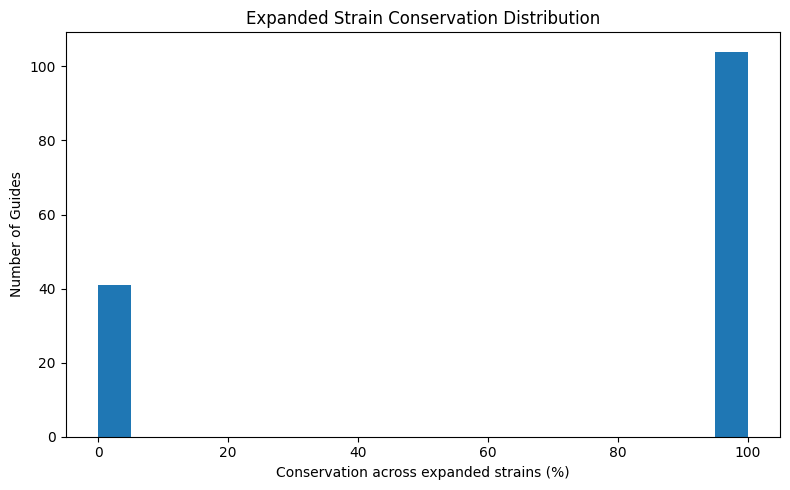

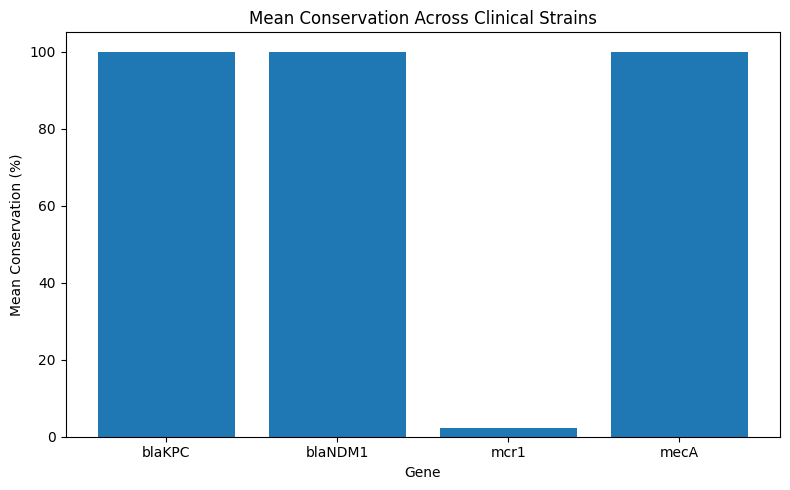

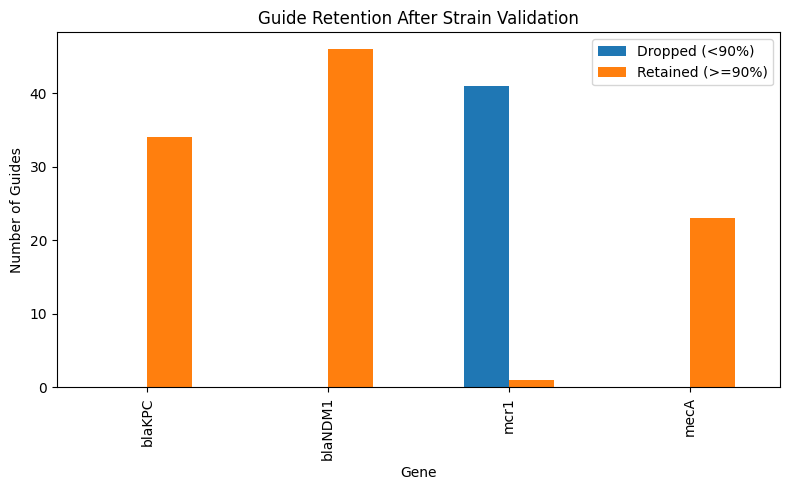

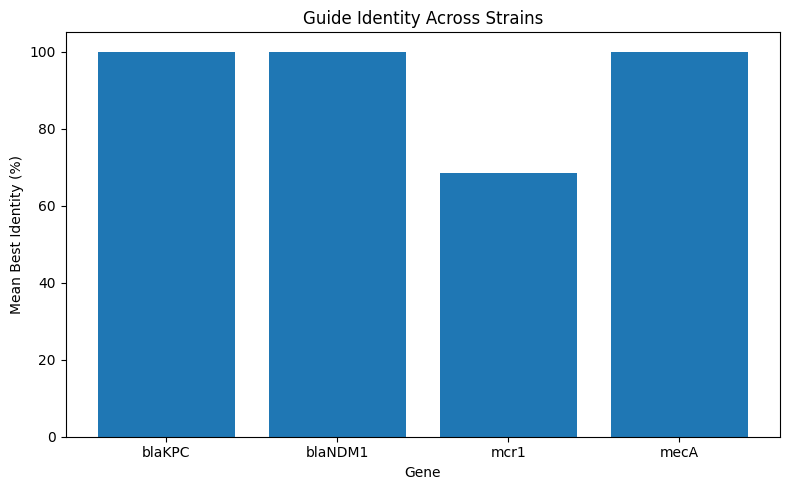

  adding: content/optionB_final_results/ (stored 0%)
  adding: content/optionB_final_results/conservation_distribution.png (deflated 27%)
  adding: content/optionB_final_results/fixed_gene_conservation_summary.csv (deflated 43%)
  adding: content/optionB_final_results/fixed_expanded_strain_conservation_guides.csv (deflated 91%)
  adding: content/optionB_final_results/gene_mean_conservation.png (deflated 28%)
  adding: content/optionB_final_results/fixed_expanded_strain_validation_report.xlsx (deflated 21%)
  adding: content/optionB_final_results/mean_best_identity.png (deflated 30%)
  adding: content/optionB_final_results/retained_vs_dropped.png (deflated 25%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
# ============================================================
# Save Option B fixed results + plots + zip + download
# ============================================================

OUTDIR = "/content/optionB_final_results"
os.makedirs(OUTDIR, exist_ok=True)

# Save CSVs
fixed_csv = f"{OUTDIR}/fixed_expanded_strain_conservation_guides.csv"
summary_csv = f"{OUTDIR}/fixed_gene_conservation_summary.csv"

fixed.to_csv(fixed_csv, index=False)
gene_summary.to_csv(summary_csv, index=False)

# Save Excel
xlsx_out = f"{OUTDIR}/fixed_expanded_strain_validation_report.xlsx"

with pd.ExcelWriter(xlsx_out, engine="openpyxl") as writer:
    fixed.to_excel(writer, sheet_name="guide_level_results", index=False)
    gene_summary.to_excel(writer, sheet_name="gene_summary", index=False)

print("Saved CSV + Excel")

# ============================================================
# Recreate all plots (final clean version)
# ============================================================

# 1. Conservation distribution
plt.figure(figsize=(8,5))
plt.hist(fixed["conservation_pct"].dropna(), bins=20)
plt.xlabel("Conservation across expanded strains (%)")
plt.ylabel("Number of Guides")
plt.title("Expanded Strain Conservation Distribution")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/conservation_distribution.png", dpi=300)
plt.show()

# 2. Mean conservation by gene
plt.figure(figsize=(8,5))
plt.bar(gene_summary["gene"], gene_summary["mean_conservation_pct"])
plt.xlabel("Gene")
plt.ylabel("Mean Conservation (%)")
plt.title("Mean Conservation Across Clinical Strains")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/gene_mean_conservation.png", dpi=300)
plt.show()

# 3. Retention plot
retention = fixed.groupby(["gene", "retained_90pct"]).size().unstack(fill_value=0)
retention = retention.reindex(columns=[False, True], fill_value=0)
retention.columns = ["Dropped (<90%)", "Retained (>=90%)"]

retention.plot(kind="bar", figsize=(8,5))
plt.xlabel("Gene")
plt.ylabel("Number of Guides")
plt.title("Guide Retention After Strain Validation")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/retained_vs_dropped.png", dpi=300)
plt.show()

# 4. Mean best identity
plt.figure(figsize=(8,5))
plt.bar(gene_summary["gene"], gene_summary["mean_best_identity"])
plt.xlabel("Gene")
plt.ylabel("Mean Best Identity (%)")
plt.title("Guide Identity Across Strains")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/mean_best_identity.png", dpi=300)
plt.show()

# ============================================================
# ZIP everything
# ============================================================

!zip -r /content/optionB_final_results.zip /content/optionB_final_results

# Download
from google.colab import files
files.download("/content/optionB_final_results.zip")